## Library Calling

In [1]:
import pandas as pd 
import numpy as np 
import os 
import scipy.stats as stats
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
import string

from sklearn.compose import make_column_selector 
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings("ignore")

## Data Cleanup and Preparation

### Loading the Data

In [ ]:
df=pd.read_excel("Customer+Churn+Data.xlsx",sheet_name="Data")

In [ ]:
df.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile


### Finding the shape and information of the table. 

In [ ]:
df.shape
print ("There are {} number of rows and {} number of columns in the dataset".format (df.shape[0],df.shape[1]))

There are 11260 number of rows and 19 number of columns in the dataset


In [ ]:
df.columns

Index(['AccountID', 'Churn', 'Tenure', 'City_Tier', 'CC_Contacted_LY',
       'Payment', 'Gender', 'Service_Score', 'Account_user_count',
       'account_segment', 'CC_Agent_Score', 'Marital_Status', 'rev_per_month',
       'Complain_ly', 'rev_growth_yoy', 'coupon_used_for_payment',
       'Day_Since_CC_connect', 'cashback', 'Login_device'],
      dtype='object')

In [ ]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

['Tenure', 'Payment', 'Gender', 'Account_user_count', 'account_segment', 'Marital_Status', 'rev_per_month', 'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback', 'Login_device']
['AccountID', 'Churn', 'City_Tier', 'CC_Contacted_LY', 'Service_Score', 'CC_Agent_Score', 'Complain_ly']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AccountID,11260.0,25629.500000,3250.626350,20000.0,22814.75,25629.5,28444.25,31259.0
Churn,11260.0,0.168384,0.374223,0.0,0.00,0.0,0.00,1.0
City_Tier,11148.0,1.653929,0.915015,1.0,1.00,1.0,3.00,3.0
CC_Contacted_LY,11158.0,17.867091,8.853269,4.0,11.00,16.0,23.00,132.0
Service_Score,11162.0,2.902526,0.725584,0.0,2.00,3.0,3.00,5.0
CC_Agent_Score,11144.0,3.066493,1.379772,1.0,2.00,3.0,4.00,5.0
Complain_ly,10903.0,0.285334,0.451594,0.0,0.00,0.0,1.00,1.0


In [ ]:
for i in df.columns:
  print("The Column - {} has {}". format(i,df[i].unique()))

The Column - AccountID has [20000 20001 20002 ... 31257 31258 31259]
The Column - Churn has [1 0]
The Column - Tenure has [4 0 2 13 11 '#' 9 99 19 20 14 8 26 18 5 30 7 1 23 3 29 6 28 24 25 16 10
 15 22 nan 27 12 21 17 50 60 31 51 61]
The Column - City_Tier has [ 3.  1. nan  2.]
The Column - CC_Contacted_LY has [  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  25.  27.  17.  23.  33.  19.  35.  24.  16.  32.  21.
  nan  34.   5.   4. 126.   7.  36. 127.  42.  38.  37.  39.  40.  41.
 132.  43. 129.]
The Column - Payment has ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan]
The Column - Gender has ['Female' 'Male' 'F' nan 'M']
The Column - Service_Score has [ 3.  2.  1. nan  0.  4.  5.]
The Column - Account_user_count has [3 4 nan 5 2 '@' 1 6]
The Column - account_segment has ['Super' 'Regular Plus' 'Regular' 'HNI' 'Regular +' nan 'Super Plus'
 'Super +']
The Column - CC_Agent_Score has [ 2.  3.  5.  4. nan  1.]
The Column - Marita

### Data Cleaning

#### Find and Replace content

In [559]:
symbol_List = list(string.punctuation)

In [ ]:
for i in df.columns:
  df[i]=df[i].apply(lambda x: np.nan if x in symbol_List else x)

In [ ]:
#pd.to_numeric(df['Tenure'], errors='raise')
#pd.to_numeric(df['City_Tier'], errors='raise')
#pd.to_numeric(df['CC_Contacted_LY'], errors='raise')
#pd.to_numeric(df['Service_Score'], errors='raise')
#pd.to_numeric(df['Account_user_count'], errors='raise')
#pd.to_numeric(df['CC_Agent_Score'], errors='raise')
#pd.to_numeric(df['rev_per_month'], errors='raise')
df.describe().T


,count,mean,std,min,25%,50%,75%,max
AccountID,11260.0,25629.500000,3250.626350,20000.0,22814.75,25629.50,28444.25,31259.0
Churn,11260.0,0.168384,0.374223,0.0,0.00,0.00,0.00,1.0
Tenure,11042.0,11.025086,12.879782,0.0,2.00,9.00,16.00,99.0
City_Tier,11148.0,1.653929,0.915015,1.0,1.00,1.00,3.00,3.0
CC_Contacted_LY,11158.0,17.867091,8.853269,4.0,11.00,16.00,23.00,132.0
Service_Score,11162.0,2.902526,0.725584,0.0,2.00,3.00,3.00,5.0
Account_user_count,10816.0,3.692862,1.022976,1.0,3.00,4.00,4.00,6.0
CC_Agent_Score,11144.0,3.066493,1.379772,1.0,2.00,3.00,4.00,5.0
rev_per_month,10469.0,6.362594,11.909686,1.0,3.00,5.00,7.00,140.0
Complain_ly,10903.0,0.285334,0.451594,0.0,0.00,0.00,1.00,1.0


In [ ]:
df['Gender']=np.where(df['Gender']=='F','Female',df['Gender'])
df['Gender']=np.where(df['Gender']=='M','Male',df['Gender'])

In [ ]:
df['account_segment']=np.where(df['account_segment']=='Regular +','Regular Plus',df['account_segment'])
df['account_segment']=np.where(df['account_segment']=='Super +','Super Plus',df['account_segment'])

In [ ]:
df['Login_device']=np.where(df['Login_device']=='&&&&',np.nan,df['Login_device'])

In [ ]:
df["Churn"]=np.where(df['Churn']==0,"No","Yes")
df["Complain_ly"]=np.where(df['Complain_ly']==0,"No","Yes")

In [ ]:
df['City_Tier'] = df['City_Tier'].map({1:'Tier-1',2:'Tier-2',3:'Tier-3'}) 

In [ ]:
for i in df.columns:
  print("The Column - {}, which is of {} data type and has: {}". format(i,df[i].dtype,df[i].unique()))
  

The Column - AccountID, which is of int64 data type and has: [20000 20001 20002 ... 31257 31258 31259]
The Column - Churn, which is of object data type and has: ['Yes' 'No']
The Column - Tenure, which is of float64 data type and has: [ 4.  0.  2. 13. 11. nan  9. 99. 19. 20. 14.  8. 26. 18.  5. 30.  7.  1.
 23.  3. 29.  6. 28. 24. 25. 16. 10. 15. 22. 27. 12. 21. 17. 50. 60. 31.
 51. 61.]
The Column - City_Tier, which is of object data type and has: ['Tier-3' 'Tier-1' nan 'Tier-2']
The Column - CC_Contacted_LY, which is of float64 data type and has: [  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  25.  27.  17.  23.  33.  19.  35.  24.  16.  32.  21.
  nan  34.   5.   4. 126.   7.  36. 127.  42.  38.  37.  39.  40.  41.
 132.  43. 129.]
The Column - Payment, which is of object data type and has: ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan]
The Column - Gender, which is of object data type and has: ['Female' 'Male' nan]
The Co

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  object 
 2   Tenure                   11042 non-null  float64
 3   City_Tier                11148 non-null  object 
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       10816 non-null  float64
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            10469 non-null  float64
 13  Complain_ly              11260 non-null  object 
 14  rev_growth_yoy        

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AccountID,11260.0,NaN,NaN,NaN,25629.5,3250.62635,20000.0,22814.75,25629.5,28444.25,31259.0
Churn,11260,2,No,9364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,11042.0,NaN,NaN,NaN,11.025086,12.879782,0.0,2.0,9.0,16.0,99.0
City_Tier,11148,3,Tier-1,7263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CC_Contacted_LY,11158.0,NaN,NaN,NaN,17.867091,8.853269,4.0,11.0,16.0,23.0,132.0
Payment,11151,5,Debit Card,4587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,11152,2,Male,6704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Service_Score,11162.0,NaN,NaN,NaN,2.902526,0.725584,0.0,2.0,3.0,3.0,5.0
Account_user_count,10816.0,NaN,NaN,NaN,3.692862,1.022976,1.0,3.0,4.0,4.0,6.0
account_segment,11163,5,Regular Plus,4124,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

['Churn', 'City_Tier', 'Payment', 'Gender', 'account_segment', 'Marital_Status', 'Complain_ly', 'Login_device']
['AccountID', 'Tenure', 'CC_Contacted_LY', 'Service_Score', 'Account_user_count', 'CC_Agent_Score', 'rev_per_month', 'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback']


#### Null Value Handling

##### Finding Null values in the data. 


In [ ]:
df.isnull().sum()
print("there are arond {} missing values in the dataset. ".format(df.isnull().sum().sum()))

there are arond 4004 missing values in the dataset. 


In [ ]:
mv=df.isnull().sum().sort_values(ascending=False)

In [ ]:
mdf = pd.DataFrame(mv,columns = ['Missing_values'])
mdf["Perc_From_Data"]=mdf["Missing_values"]/len(df)*100
mdf

,Missing_values,Perc_From_Data
rev_per_month,791,7.024867
Login_device,760,6.749556
cashback,473,4.200710
Account_user_count,444,3.943162
Day_Since_CC_connect,358,3.179396
Tenure,218,1.936057
Marital_Status,212,1.882771
CC_Agent_Score,116,1.030195
City_Tier,112,0.994671
Payment,109,0.968028


In [ ]:
df[df.isnull().any(axis=1)]

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
2,20002,Yes,0.0,Tier-1,30.0,Debit Card,Male,2.0,4.0,Regular Plus,3.0,Single,6.0,Yes,14.0,0.0,3.0,NaN,Mobile
5,20005,Yes,0.0,Tier-1,22.0,Debit Card,Female,3.0,NaN,Regular Plus,5.0,Single,2.0,Yes,22.0,4.0,7.0,139.19,Computer
10,20010,Yes,4.0,NaN,18.0,Cash on Delivery,Female,2.0,3.0,Regular,3.0,Divorced,2.0,No,12.0,9.0,8.0,295.45,Mobile
12,20012,Yes,NaN,Tier-1,11.0,Cash on Delivery,Male,2.0,3.0,Regular Plus,3.0,Single,2.0,Yes,13.0,2.0,2.0,134.41,Mobile
15,20015,Yes,NaN,Tier-2,12.0,UPI,Male,3.0,3.0,Regular Plus,5.0,Married,5.0,Yes,22.0,1.0,2.0,120.73,Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11240,31240,No,9.0,Tier-2,38.0,Debit Card,Female,3.0,4.0,HNI,1.0,Single,3.0,Yes,17.0,2.0,8.0,213.37,NaN
11242,31242,Yes,14.0,Tier-3,13.0,NaN,Male,4.0,4.0,Super,3.0,Married,11.0,No,13.0,2.0,2.0,197.28,NaN
11247,31247,No,14.0,Tier-1,12.0,Credit Card,Female,4.0,4.0,Regular Plus,3.0,Married,NaN,Yes,15.0,1.0,3.0,145.01,Mobile
11251,31251,Yes,14.0,Tier-3,37.0,E wallet,Male,3.0,5.0,HNI,5.0,Married,9.0,Yes,14.0,3.0,NaN,240.54,Mobile


##### Treating the null Values in the data (knn imputer- Continuous & Simple imputer- Categorical)

In [ ]:
## Treating the null value for Continuous Variable
from sklearn.impute import KNNImputer
imputer_num = KNNImputer(n_neighbors=3)
df_CC_num = pd.DataFrame(imputer_num.fit_transform(df[num]),columns = df[num].columns)


In [ ]:
## Treating the null value for Continuous Variable
from sklearn.impute import SimpleImputer
imputer_cat = SimpleImputer(strategy = 'most_frequent')
df_CC_cat = pd.DataFrame(imputer_cat.fit_transform(df[cat]),columns = df[cat].columns)


In [ ]:
df = df_CC_num.join(df_CC_cat)
df.head()

,AccountID,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Churn,City_Tier,Payment,Gender,account_segment,Marital_Status,Complain_ly,Login_device
0,20000.0,4.0,6.0,3.0,3.0,2.0,9.0,11.0,1.0,5.0,159.930000,Yes,Tier-3,Debit Card,Female,Super,Single,Yes,Mobile
1,20001.0,0.0,8.0,3.0,4.0,3.0,7.0,15.0,0.0,0.0,120.900000,Yes,Tier-1,UPI,Male,Regular Plus,Single,Yes,Mobile
2,20002.0,0.0,30.0,2.0,4.0,3.0,6.0,14.0,0.0,3.0,132.063333,Yes,Tier-1,Debit Card,Male,Regular Plus,Single,Yes,Mobile
3,20003.0,0.0,15.0,2.0,4.0,5.0,8.0,23.0,0.0,3.0,134.070000,Yes,Tier-3,Debit Card,Male,Super,Single,No,Mobile
4,20004.0,0.0,12.0,2.0,3.0,5.0,3.0,11.0,1.0,3.0,129.600000,Yes,Tier-1,Credit Card,Male,Regular Plus,Single,No,Mobile


In [ ]:
for i in num:
    df[i] = np.round(df[i],0)
df['Service_Score'] = np.where(df['Service_Score'] == 0,1,df['Service_Score'])

In [ ]:
print("there are arond {} missing values in the dataset. ".format(df.isnull().sum().sum()))

there are arond 0 missing values in the dataset. 


In [ ]:
for i in df.columns:
  print("The Column - {} has {}". format(i,df[i].unique()))

The Column - AccountID has [20000. 20001. 20002. ... 31257. 31258. 31259.]
The Column - Tenure has [ 4.  0.  2. 13. 11.  9.  1. 99. 19. 20. 14.  8. 26. 18.  5. 30.  7. 23.
  3. 29.  6. 28. 24. 25. 16. 10. 15. 22. 12. 27. 21. 17. 50. 33. 60. 31.
 35. 51. 46. 67. 44. 61. 43. 38. 41. 37.]
The Column - CC_Contacted_LY has [  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  25.  27.  17.  23.  33.  19.  35.  24.  16.  32.  21.
  34.   5.   4. 126.   7.  36. 127.  42.  38.  37.  39.  40.  41. 132.
  43. 129.]
The Column - Service_Score has [3. 2. 1. 4. 5.]
The Column - Account_user_count has [3. 4. 5. 2. 1. 6.]
The Column - CC_Agent_Score has [2. 3. 5. 4. 1.]
The Column - rev_per_month has [  9.   7.   6.   8.   3.   2.   4.  10.   1.   5. 130.  19. 139. 102.
  42. 120. 138. 127. 123. 124. 116.  21.  48.  50. 126. 134. 113.  38.
 114.  41. 108. 140.  47. 133. 129. 107. 118.  11. 105.  46.  53.  20.
 119.  45. 121. 137. 110.  22.  37. 101. 136. 125.  14.  1

#### Duplicate Value Handling

##### Finding Duplicate Values

In [ ]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
df.loc[df.duplicated(keep=False), :]

Number of duplicate rows = 0


,AccountID,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Churn,City_Tier,Payment,Gender,account_segment,Marital_Status,Complain_ly,Login_device


#### Unwanted value handling. 


In [ ]:
df.drop("AccountID", axis=1, inplace=True)

### EDA

#### Univariate Analysis of Continuous Variable

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,11260.0,11.015187,12.815381,0.0,2.0,9.0,16.0,99.0
CC_Contacted_LY,11260.0,17.860213,8.826459,4.0,11.0,16.0,23.0,132.0
Service_Score,11260.0,2.903641,0.723187,1.0,2.0,3.0,3.0,5.0
Account_user_count,11260.0,3.691119,1.013442,1.0,3.0,4.0,4.0,6.0
CC_Agent_Score,11260.0,3.065542,1.375681,1.0,2.0,3.0,4.0,5.0
rev_per_month,11260.0,6.351155,11.612942,1.0,3.0,5.0,7.0,140.0
rev_growth_yoy,11260.0,16.192718,3.757455,4.0,13.0,15.0,19.0,28.0
coupon_used_for_payment,11260.0,1.790764,1.969323,0.0,1.0,1.0,2.0,16.0
Day_Since_CC_connect,11260.0,4.628508,3.661237,0.0,2.0,3.0,7.0,47.0
cashback,11260.0,196.149467,176.228575,0.0,147.0,166.0,200.0,1997.0


In [ ]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

['Churn', 'City_Tier', 'Payment', 'Gender', 'account_segment', 'Marital_Status', 'Complain_ly', 'Login_device']
['Tenure', 'CC_Contacted_LY', 'Service_Score', 'Account_user_count', 'CC_Agent_Score', 'rev_per_month', 'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback']


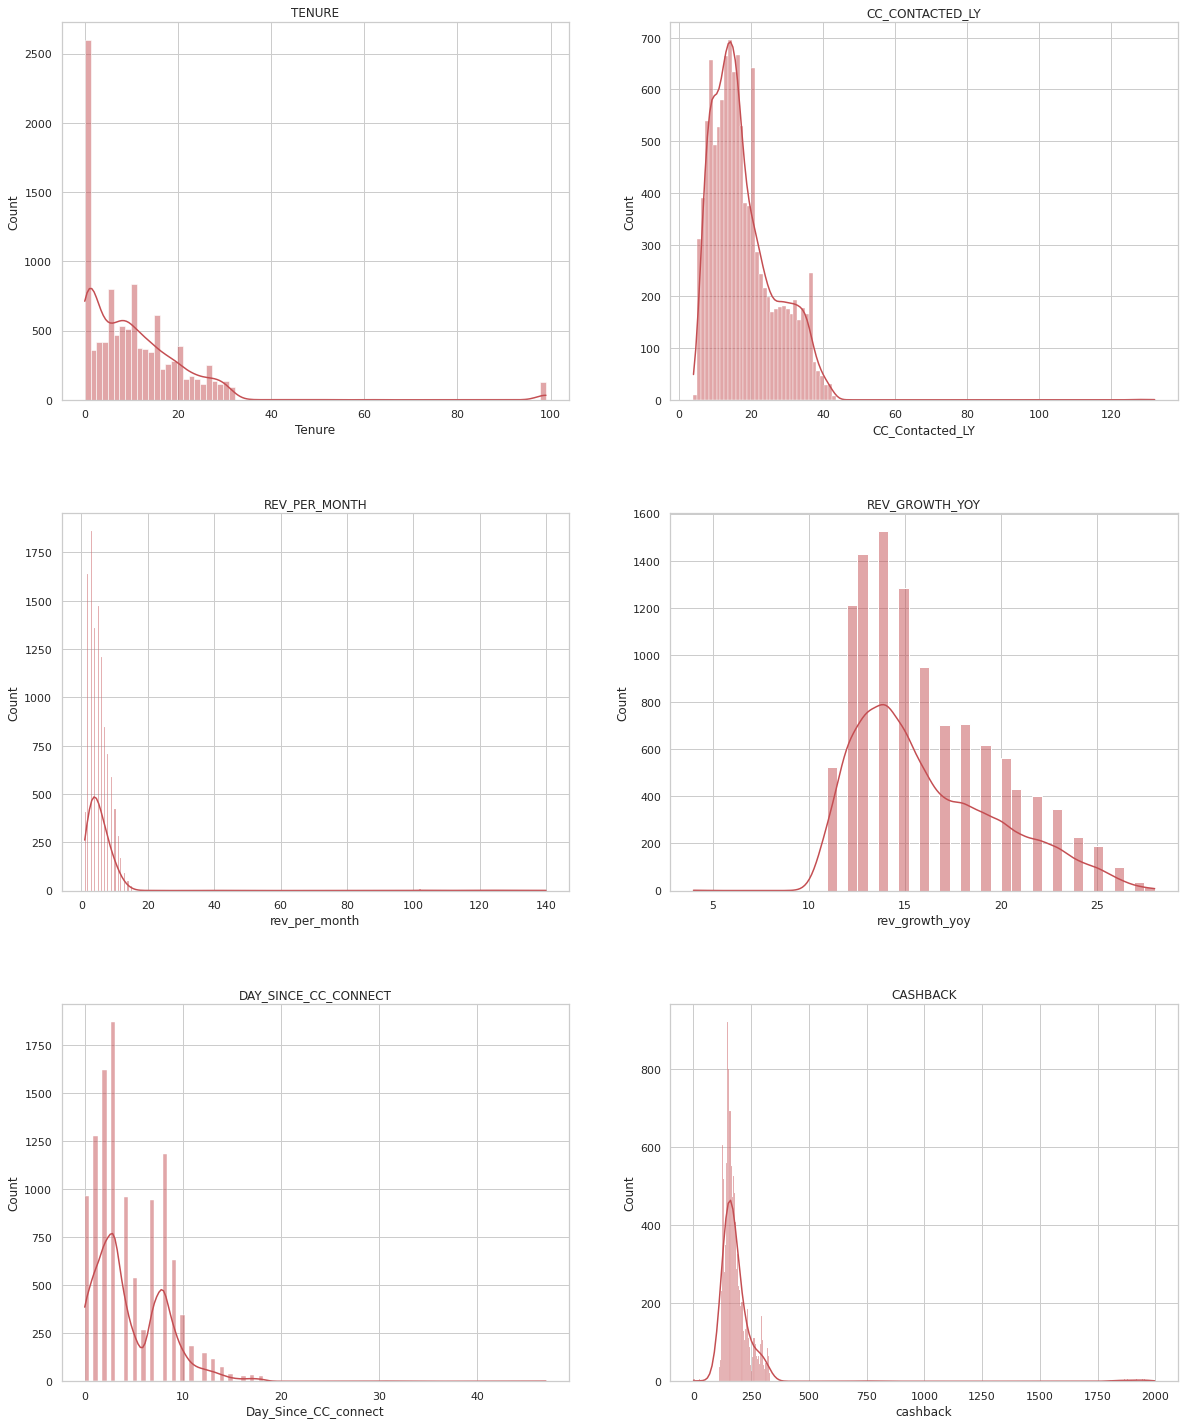

In [ ]:
con_var=[
 'Tenure',
 'CC_Contacted_LY', 
 'rev_per_month',
 'rev_growth_yoy',
 'Day_Since_CC_connect',
 'cashback']
fig,axes = plt.subplots(3,2,figsize=(20,25))
plt.subplots_adjust(hspace=0.3,wspace=0.2)
for i,j in zip(con_var,axes.flatten()):
    sns.histplot(x=i,data = df,ax=j,kde=True,color='r')
    j.set_title(i.upper())

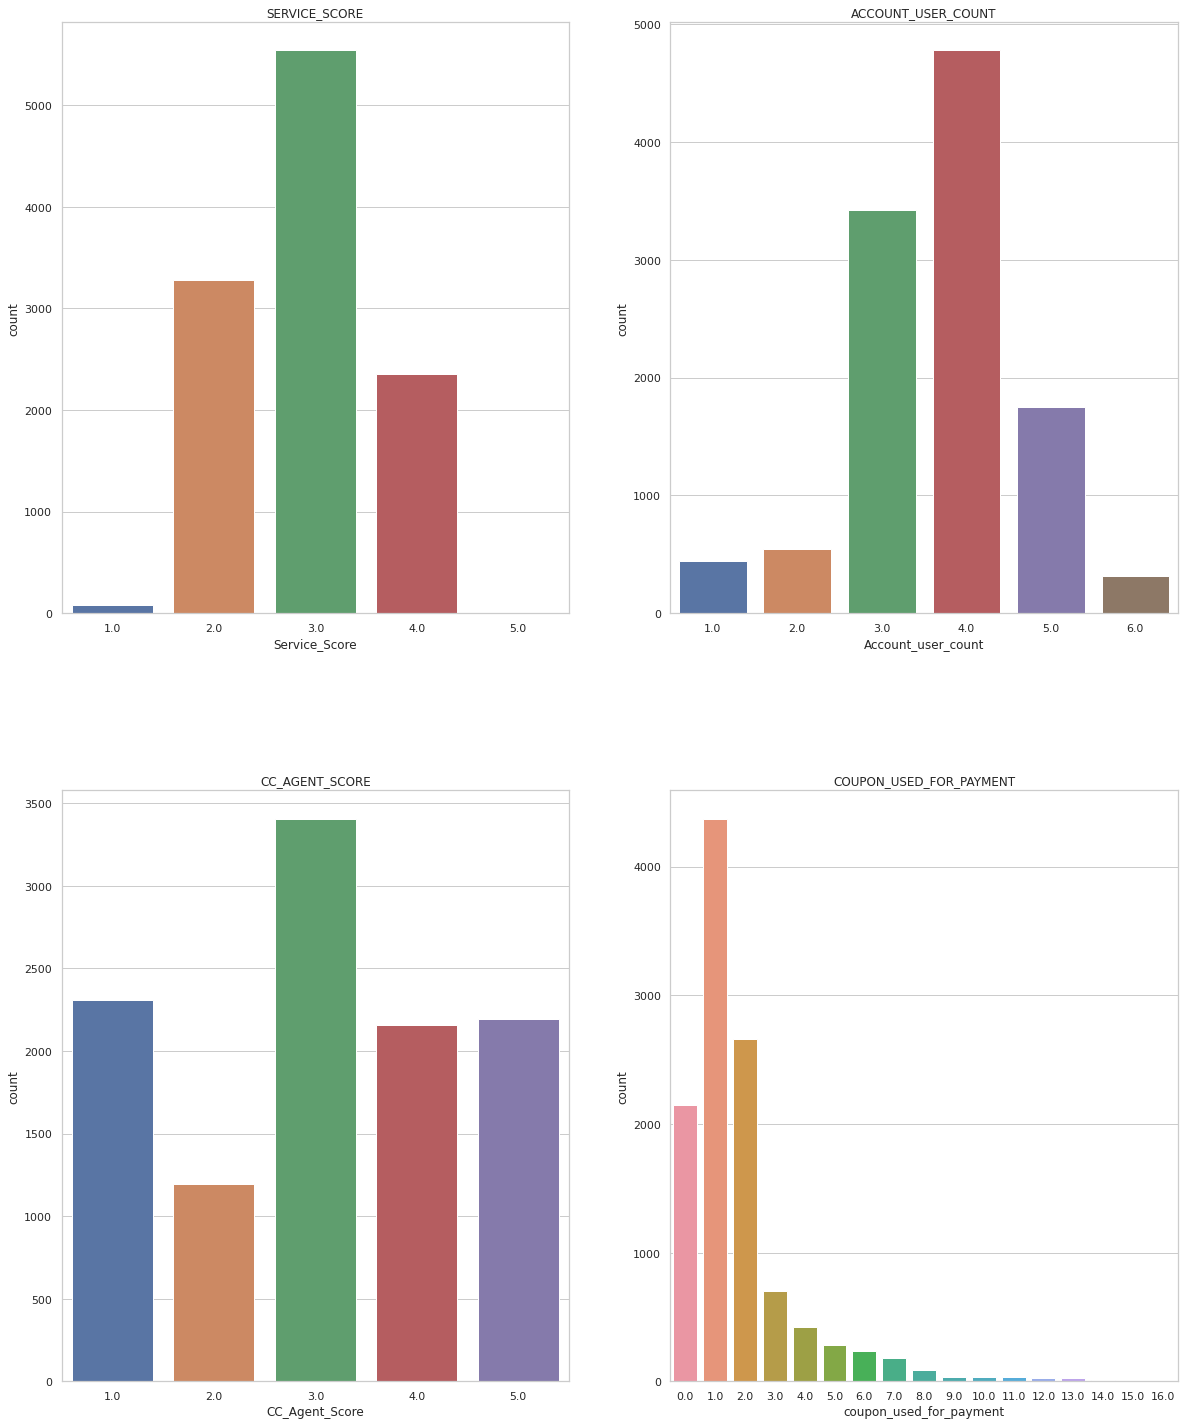

In [ ]:
ord_var = ['Service_Score','Account_user_count','CC_Agent_Score','coupon_used_for_payment']
fig,axes = plt.subplots(2,2,figsize=(20,25))
plt.subplots_adjust(hspace=0.3,wspace=0.2)
for i,j in zip(ord_var,axes.flatten()):
    sns.countplot(x=i,data = df,ax=j,)
    j.set_title(i.upper())

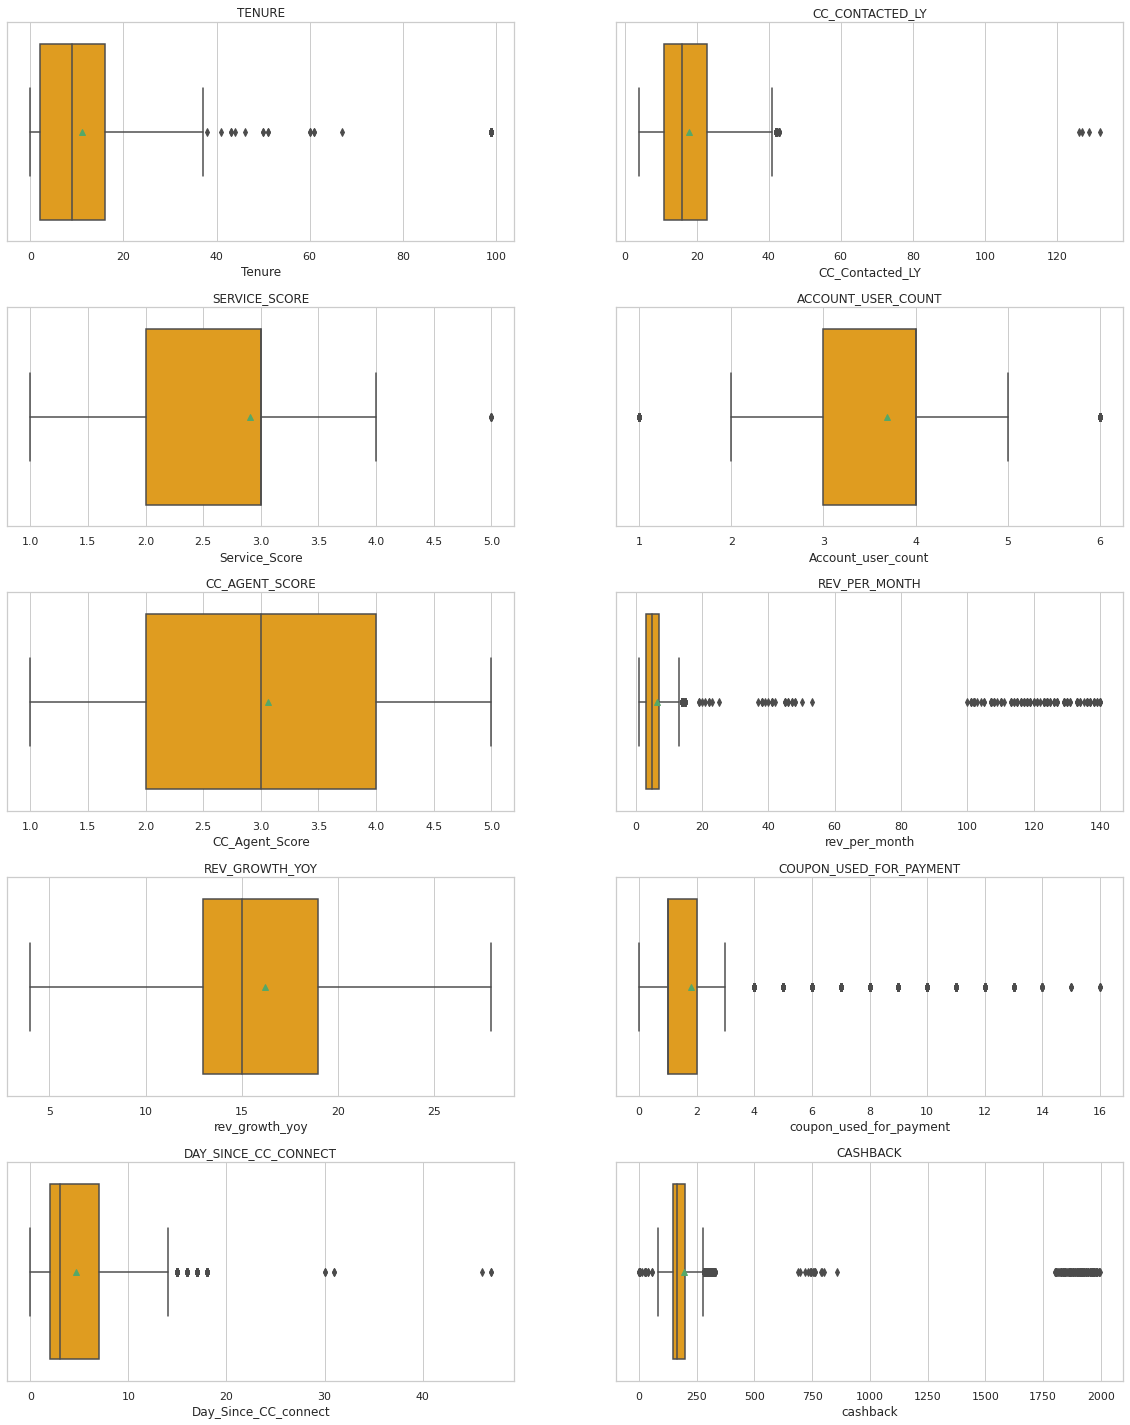

In [ ]:
fig,axes = plt.subplots(5,2,figsize=(20,25))
plt.subplots_adjust(hspace=0.3,wspace=0.2)
for i,j in zip(num,axes.flatten()):
  sns.boxplot(x=i,data = df,ax=j,showmeans=True,color="orange")
  j.set_title(i.upper())


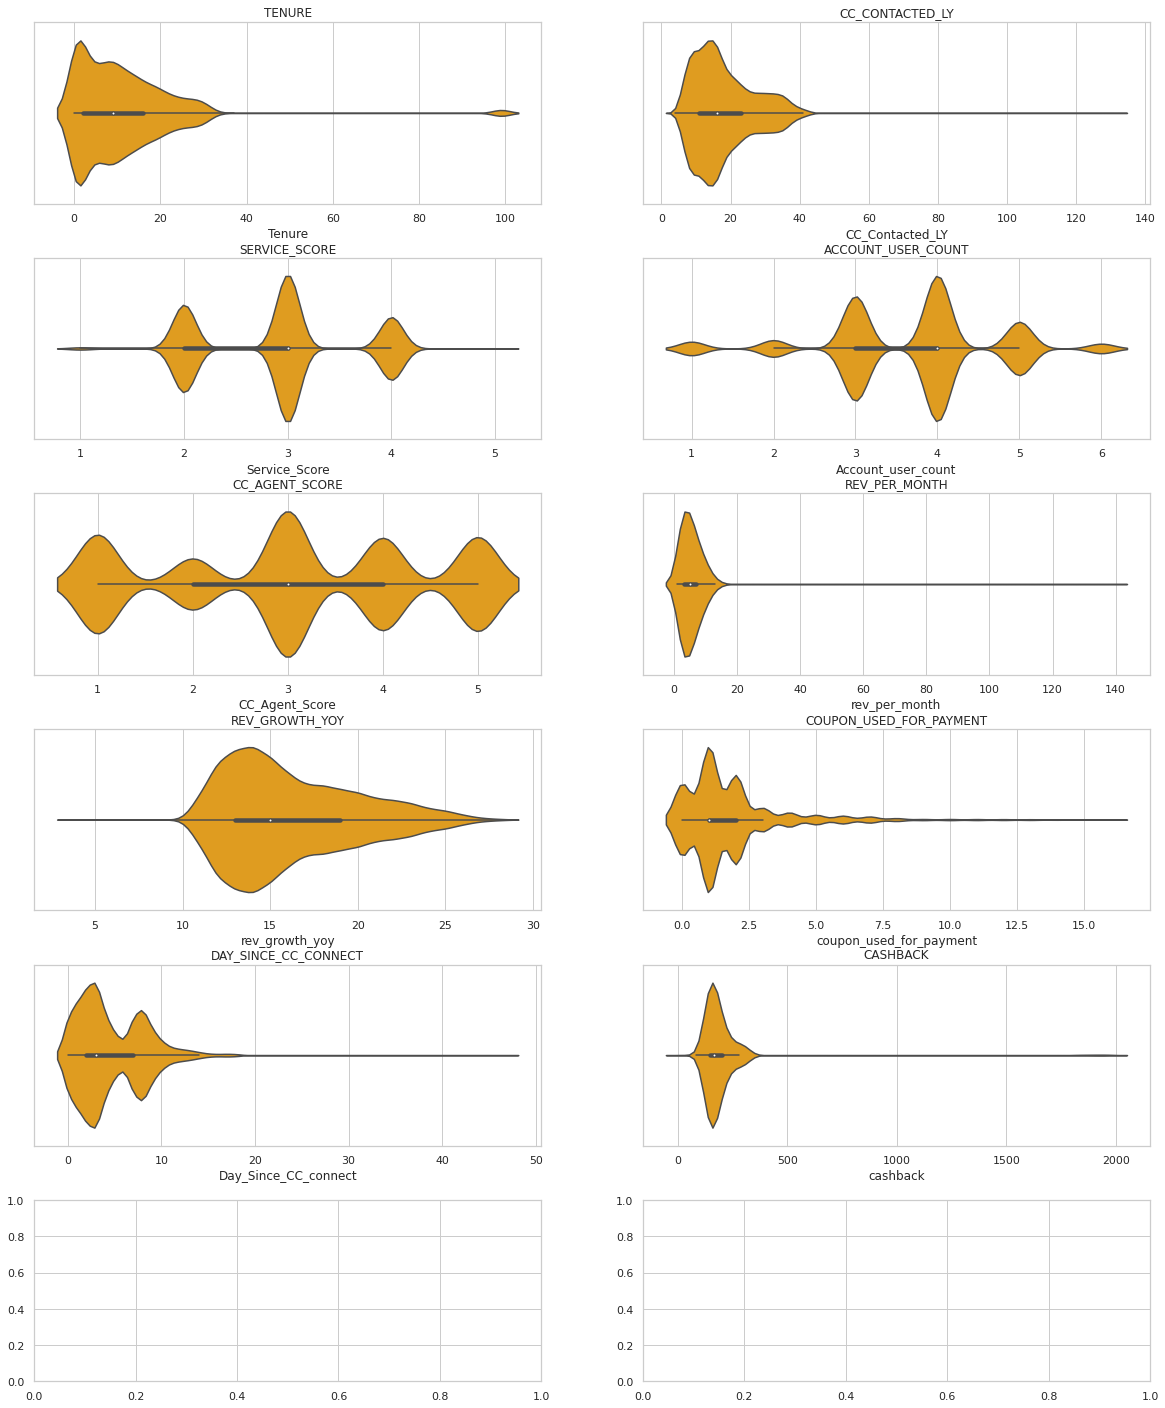

In [ ]:
fig,axes = plt.subplots(6,2,figsize=(20,25))
plt.subplots_adjust(hspace=0.3,wspace=0.2)
for i,j in zip(num,axes.flatten()):
  sns.violinplot(x=i,data = df,ax=j,color="orange")
  j.set_title(i.upper())

#### Univariate Analysis of Categorical Variable

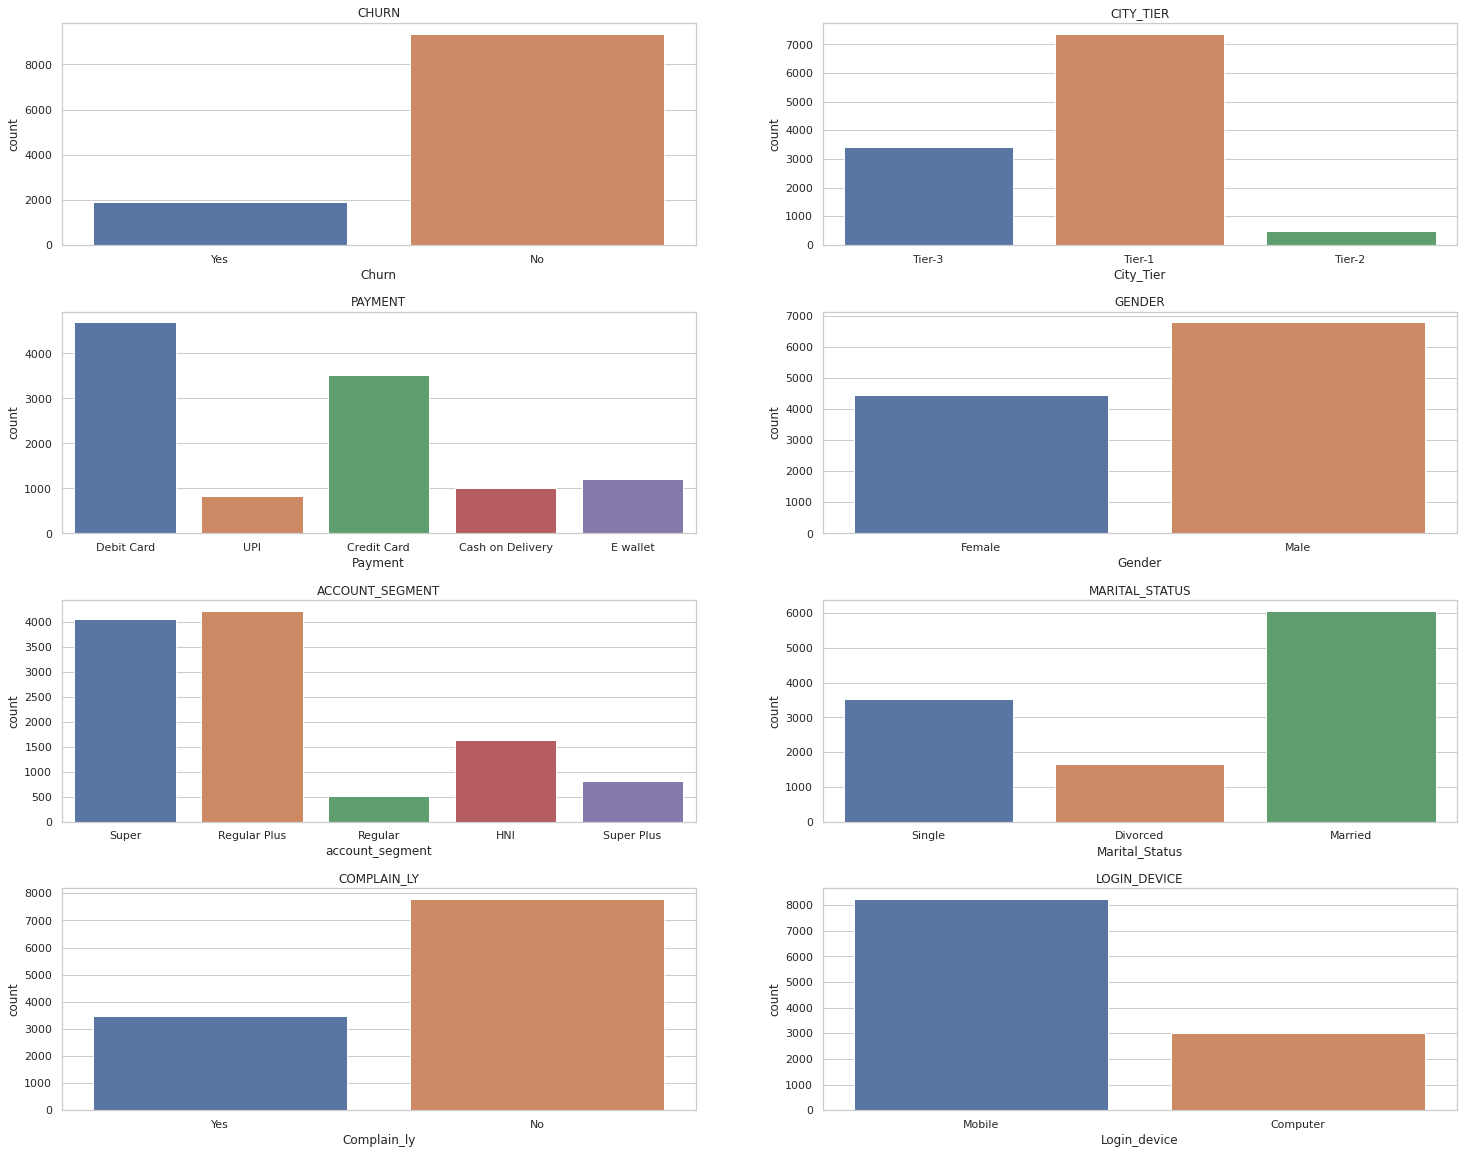

In [ ]:
fig,axes = plt.subplots(4,2,figsize=(25,20))
plt.subplots_adjust(wspace=0.2,hspace=0.3)
for i,j in zip(cat,axes.flatten()):
    sns.countplot(x=i,data = df,ax=j)
    j.set_title(i.upper())

#### Bivariate Analyisis

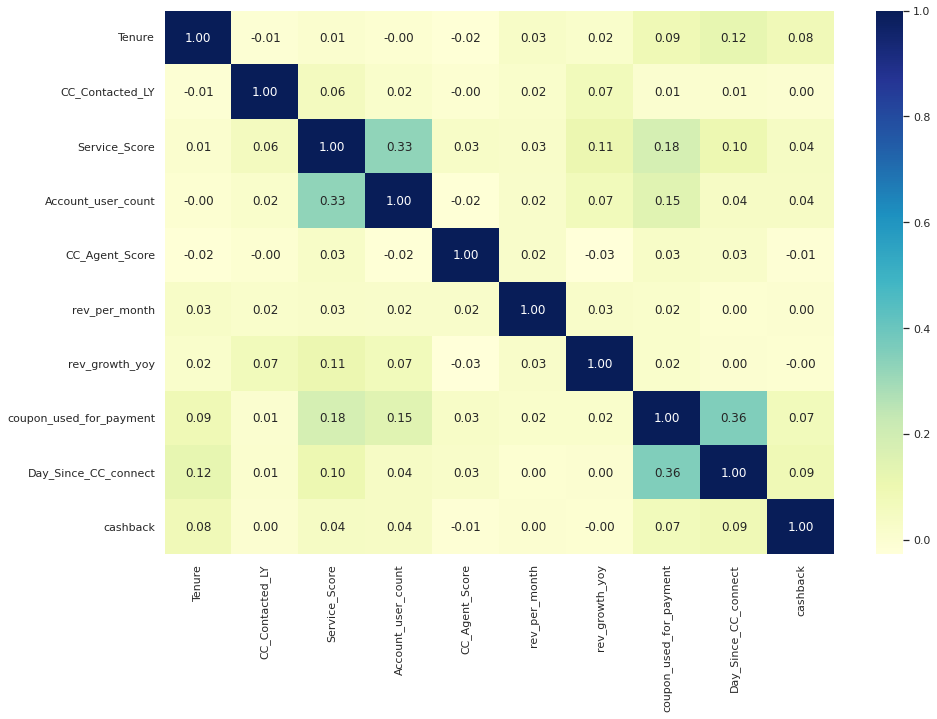

In [ ]:
fig = plt.subplots(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True,fmt='.2f',cmap="YlGnBu");
plt.show()

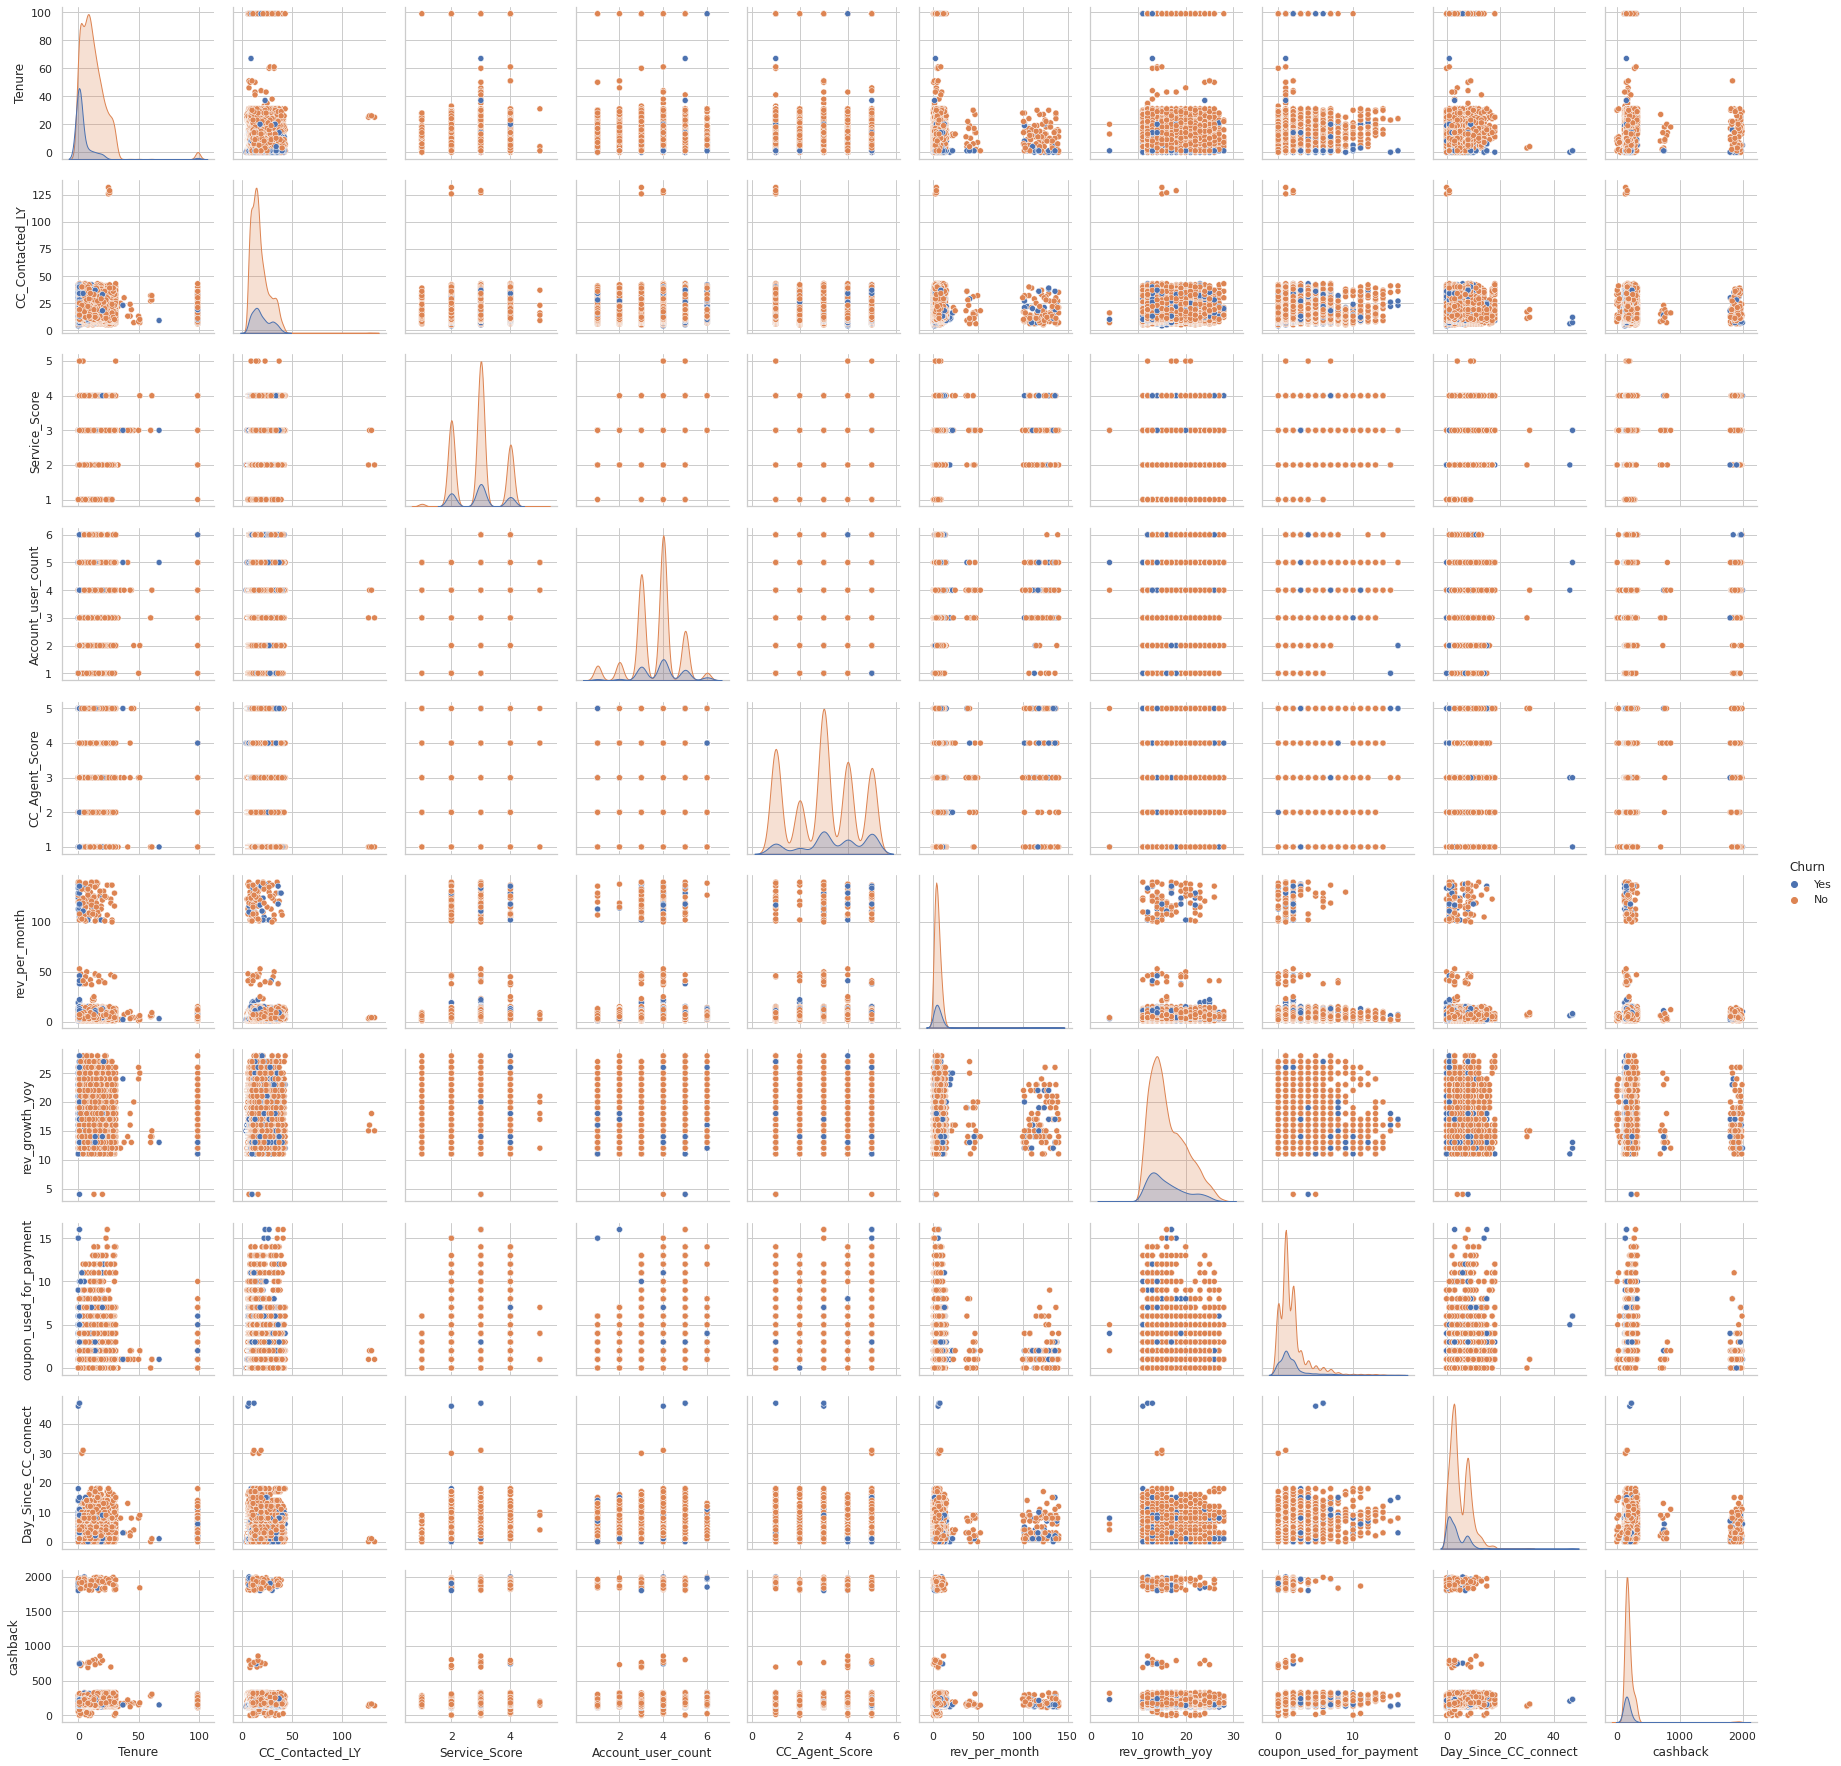

In [ ]:
sns.pairplot(df, diag_kind='kde',hue="Churn");

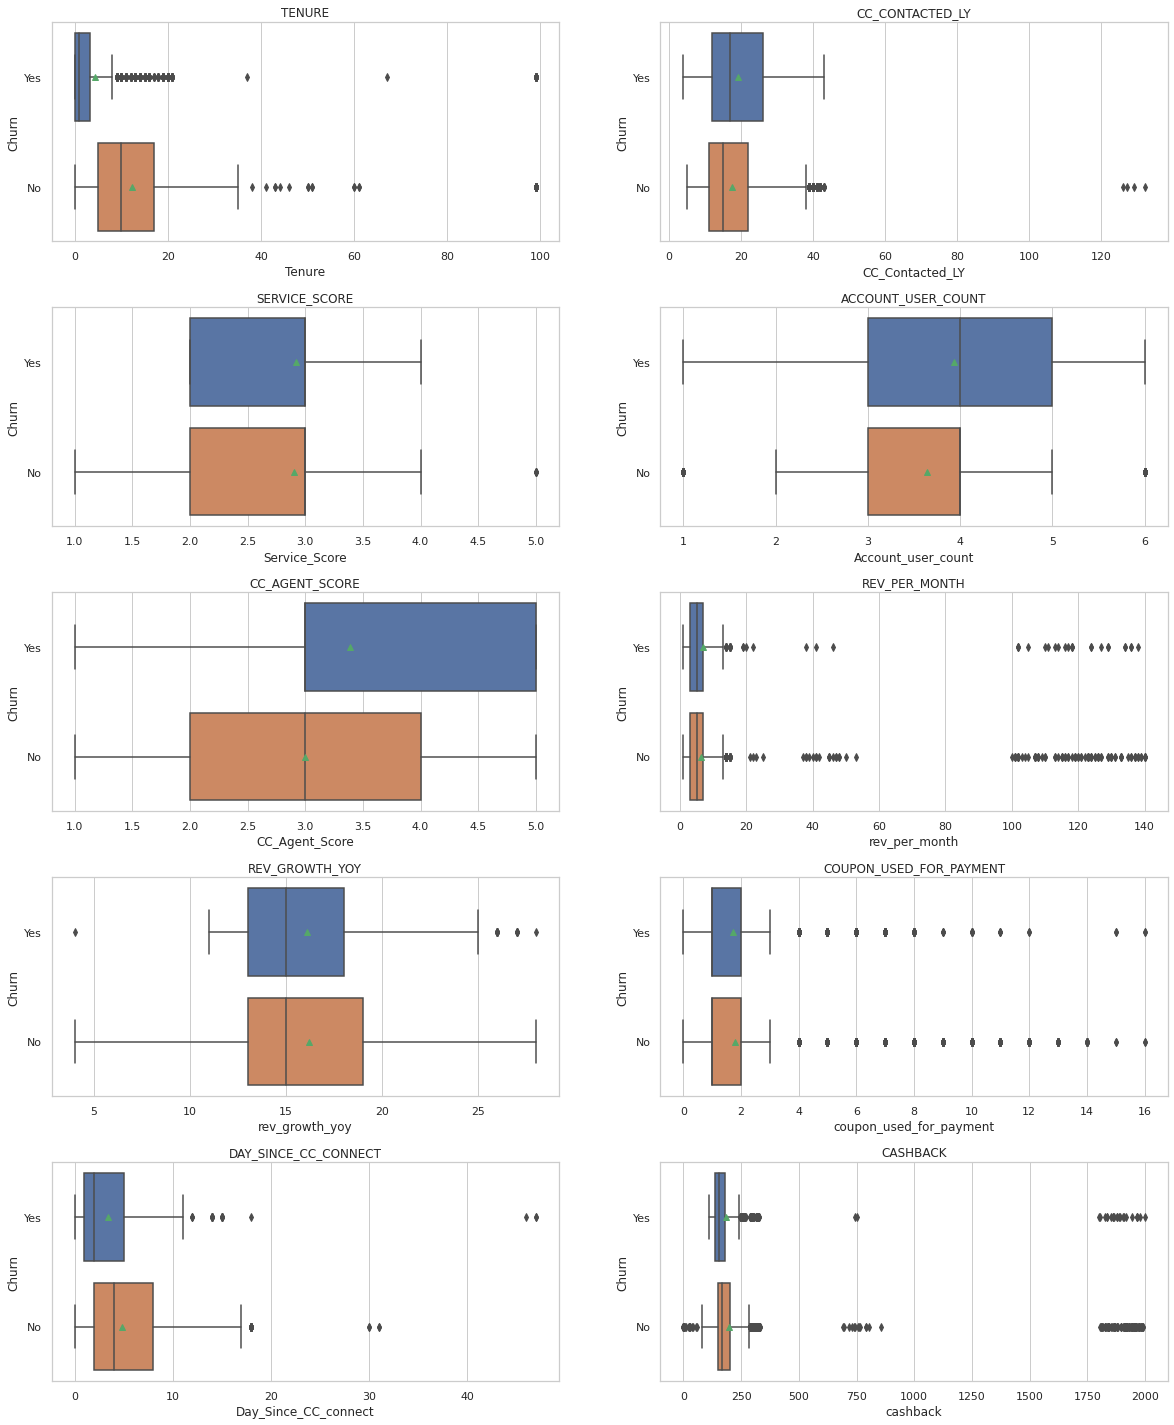

In [ ]:
fig,axes = plt.subplots(5,2,figsize=(20,25))
plt.subplots_adjust(hspace=0.3,wspace=0.2)
for i,j in zip(num,axes.flatten()):
  sns.boxplot(x=i,data = df,ax=j,showmeans=True, y="Churn")
  j.set_title(i.upper())

In [593]:
import itertools
iter_temp = list(itertools.combinations_with_replacement(cat,2))
list_1=[('Churn','Churn'),('City_Tier','City_Tier'),('Payment','Payment'),('Gender','Gender'),('account_segment','account_segment'),('Marital_Status','Marital_Status'),('Complain_ly','Complain_ly'),('Login_device','Login_device')]

iter = list(set(iter_temp) - set(list_1))
len(iter)

28

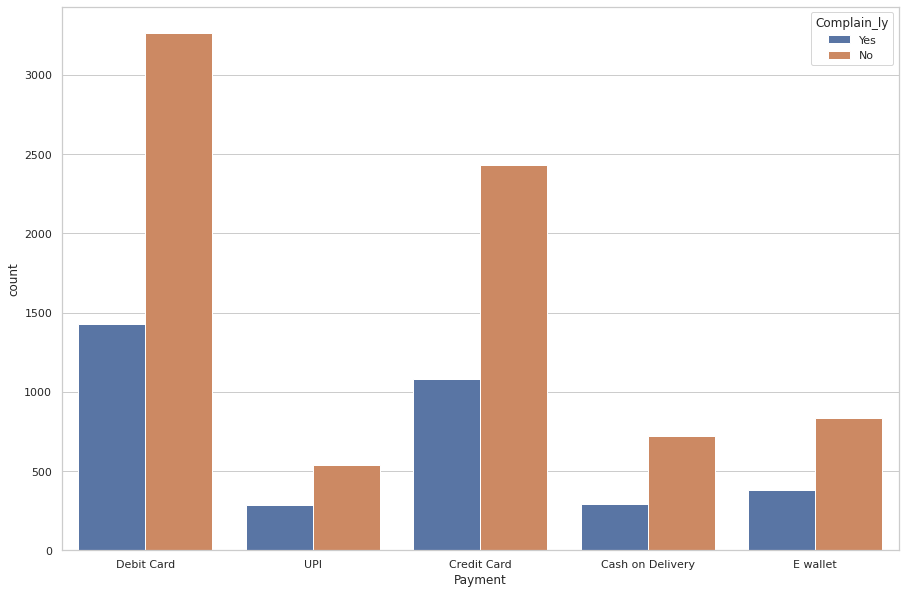

-----------------------------------------------


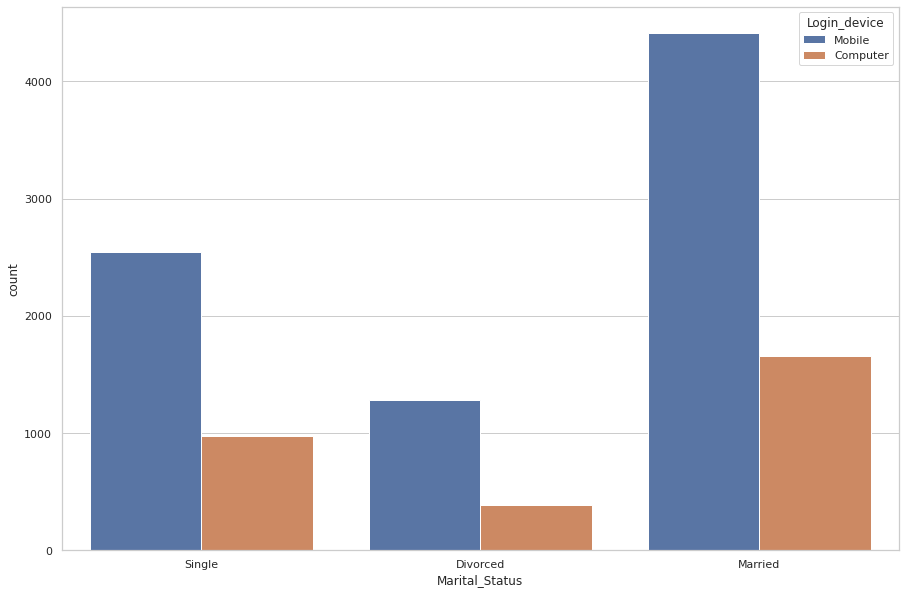

-----------------------------------------------


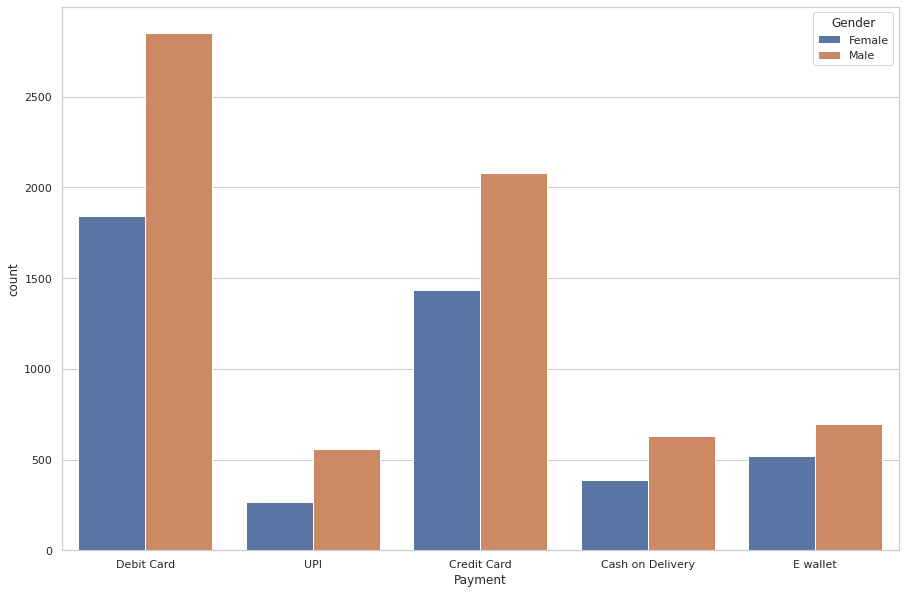

-----------------------------------------------


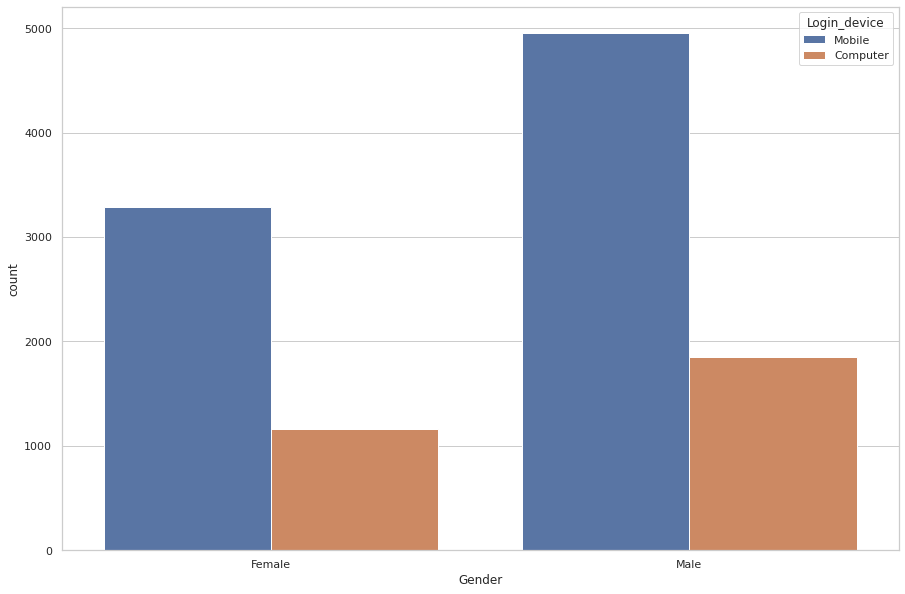

-----------------------------------------------


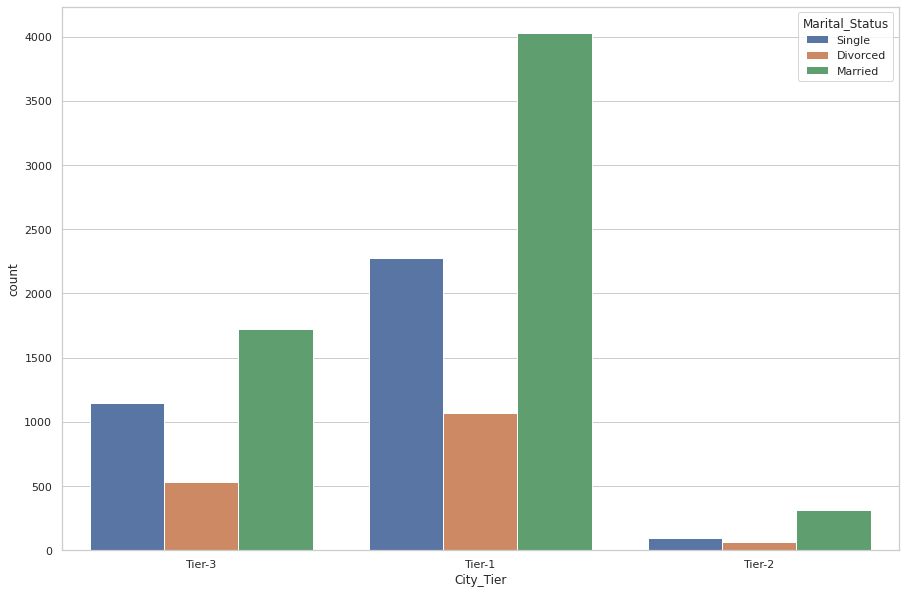

-----------------------------------------------


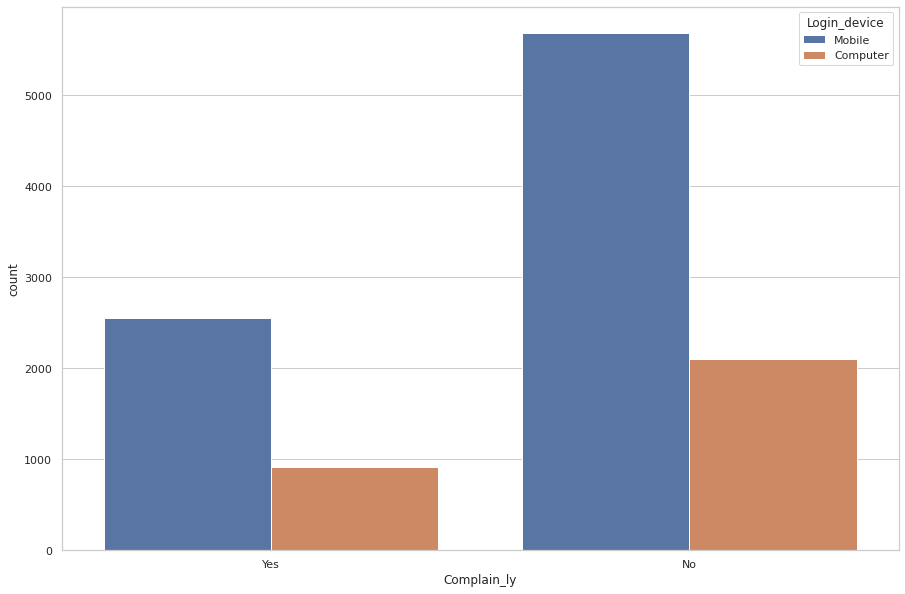

-----------------------------------------------


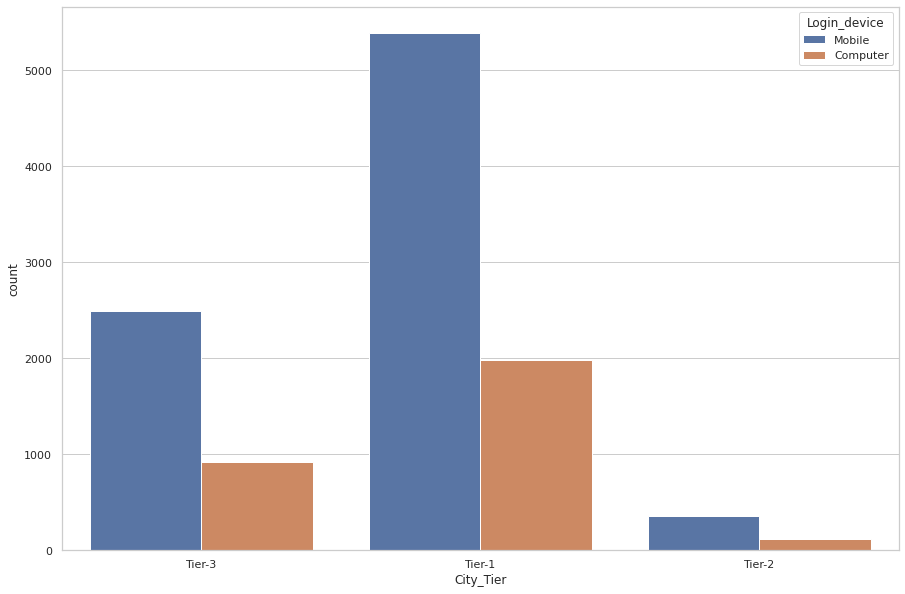

-----------------------------------------------


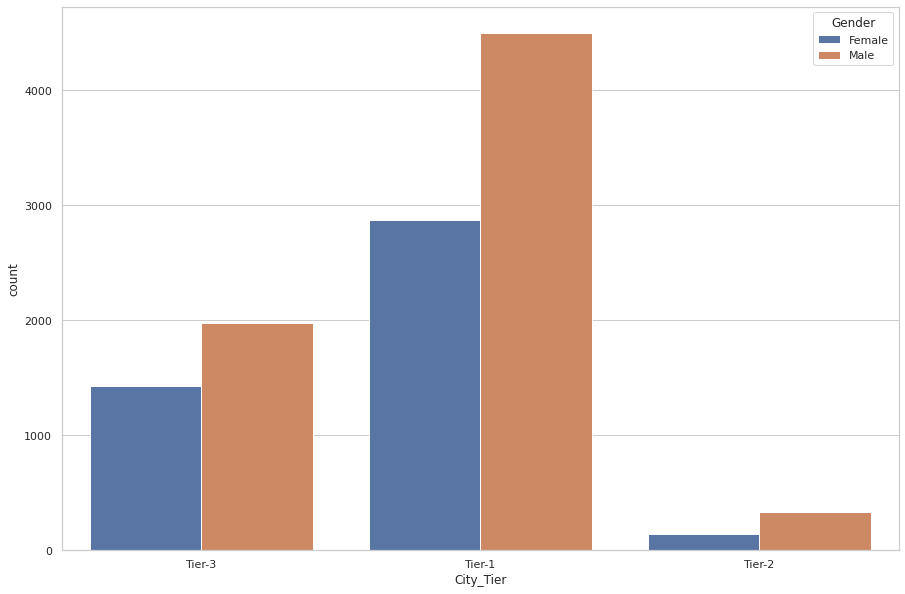

-----------------------------------------------


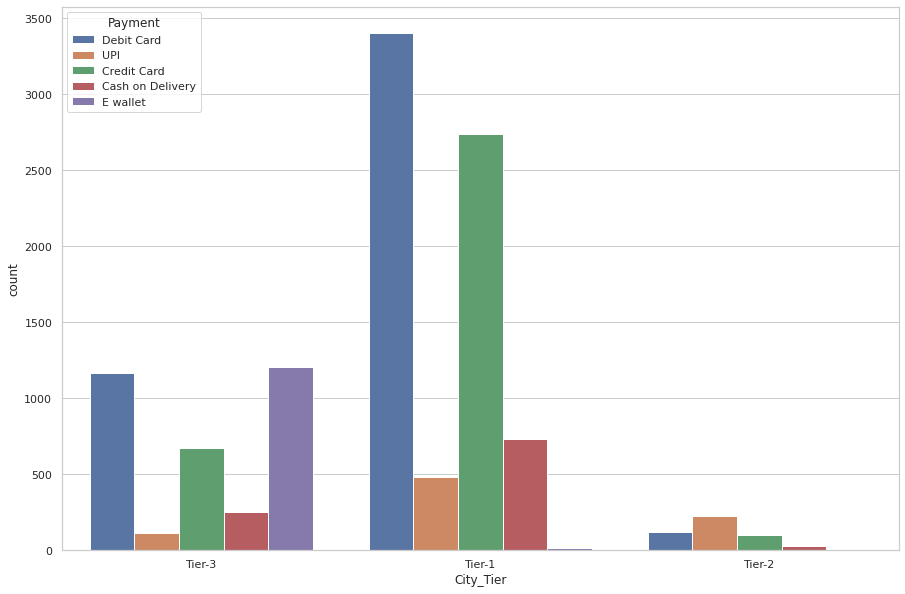

-----------------------------------------------


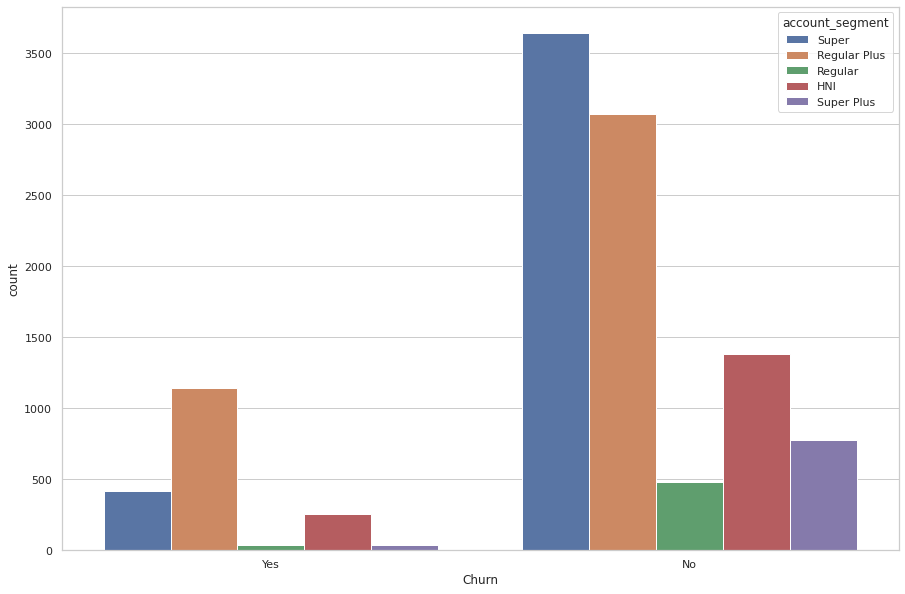

-----------------------------------------------


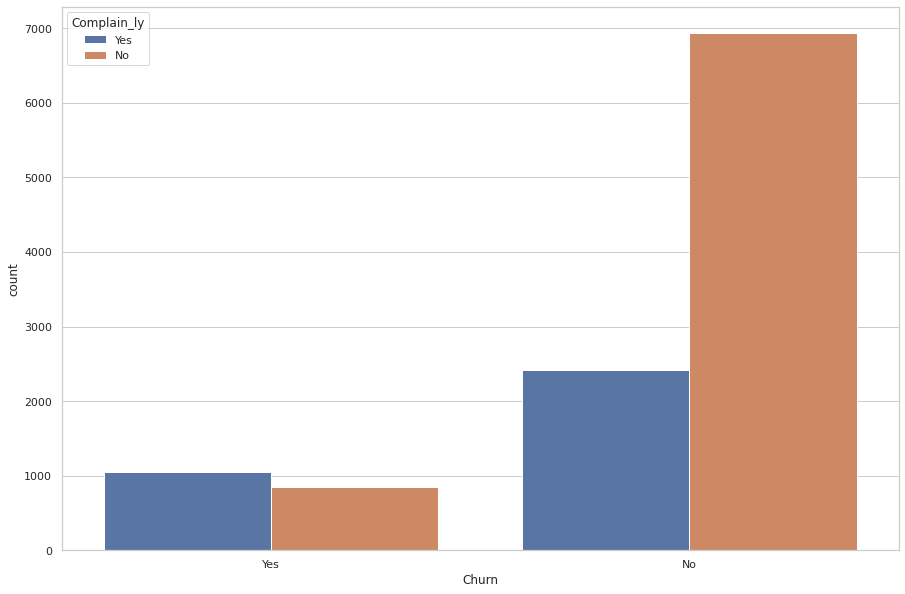

-----------------------------------------------


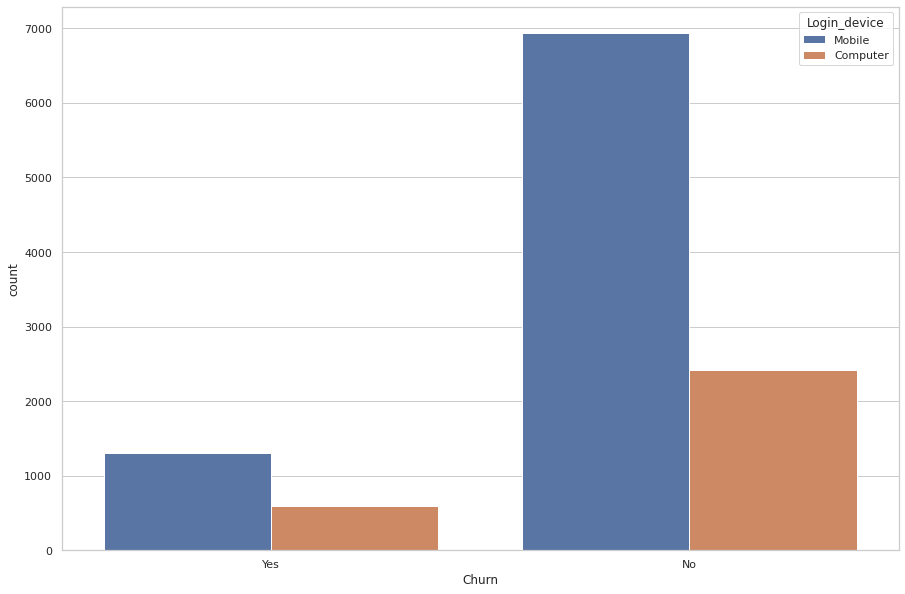

-----------------------------------------------


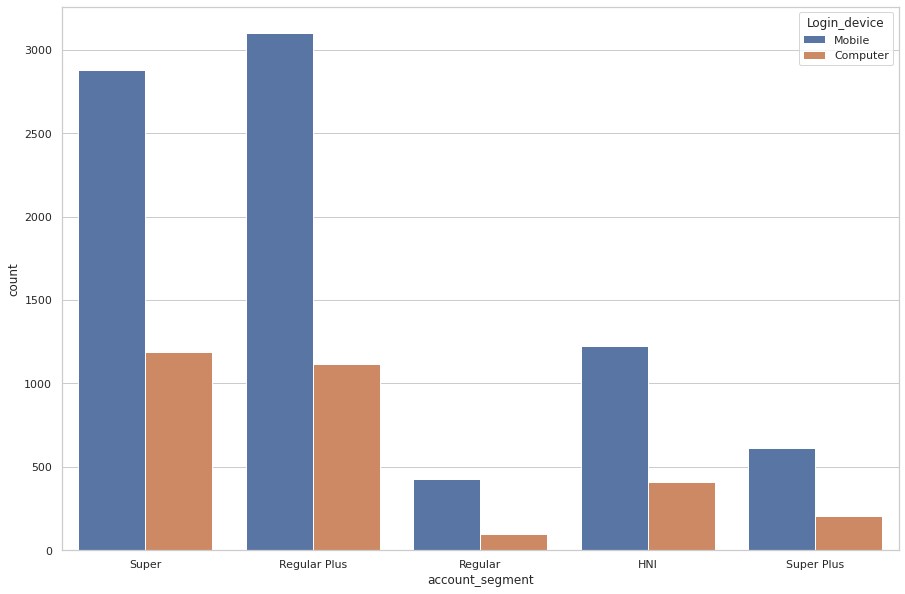

-----------------------------------------------


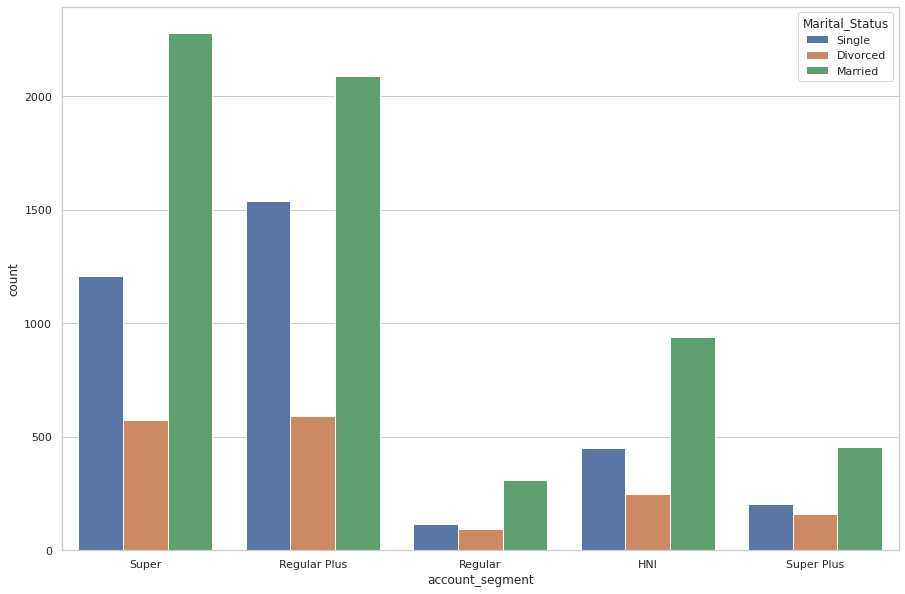

-----------------------------------------------


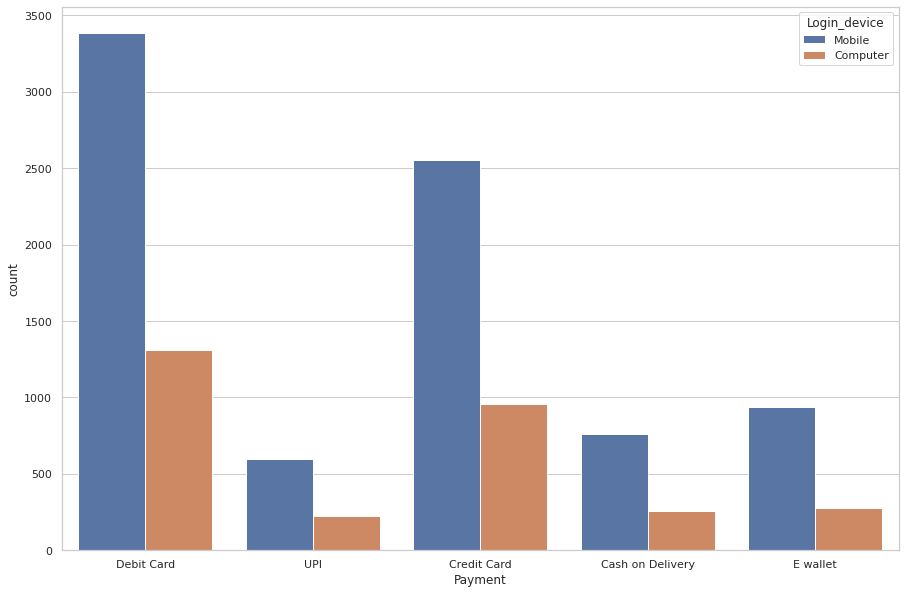

-----------------------------------------------


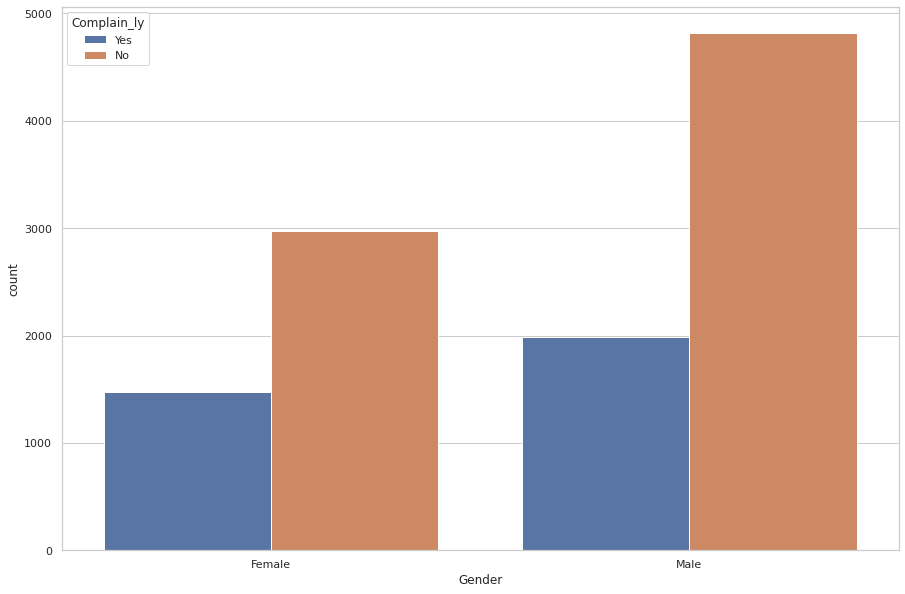

-----------------------------------------------


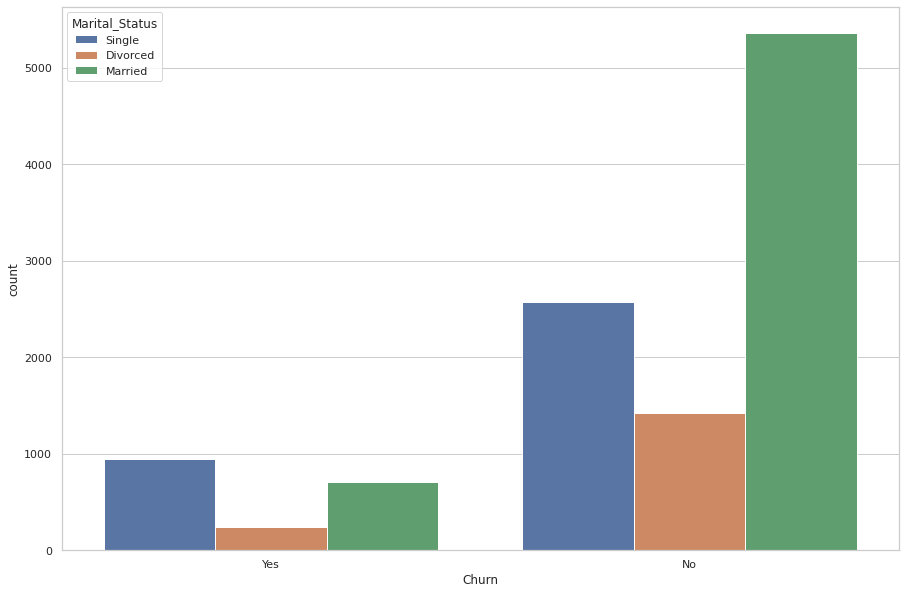

-----------------------------------------------


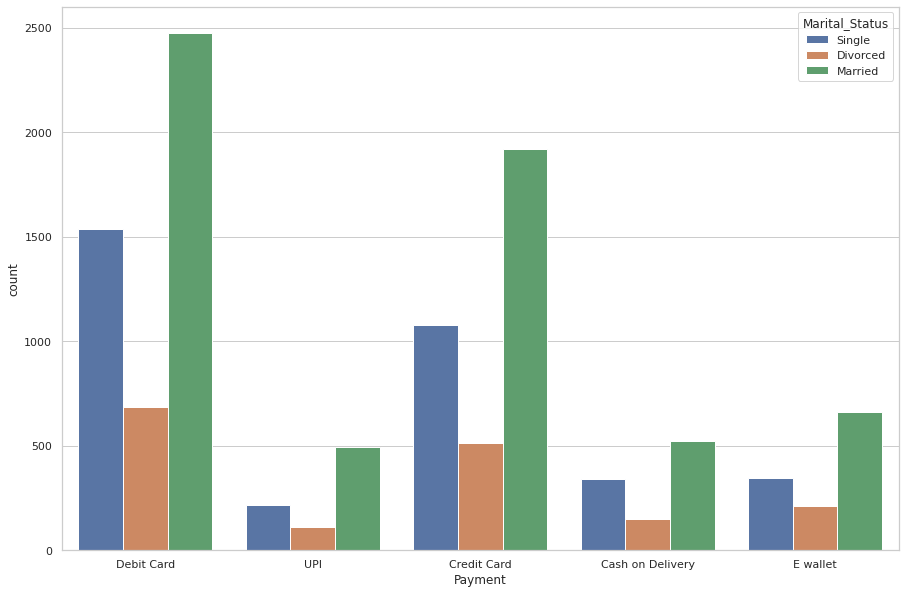

-----------------------------------------------


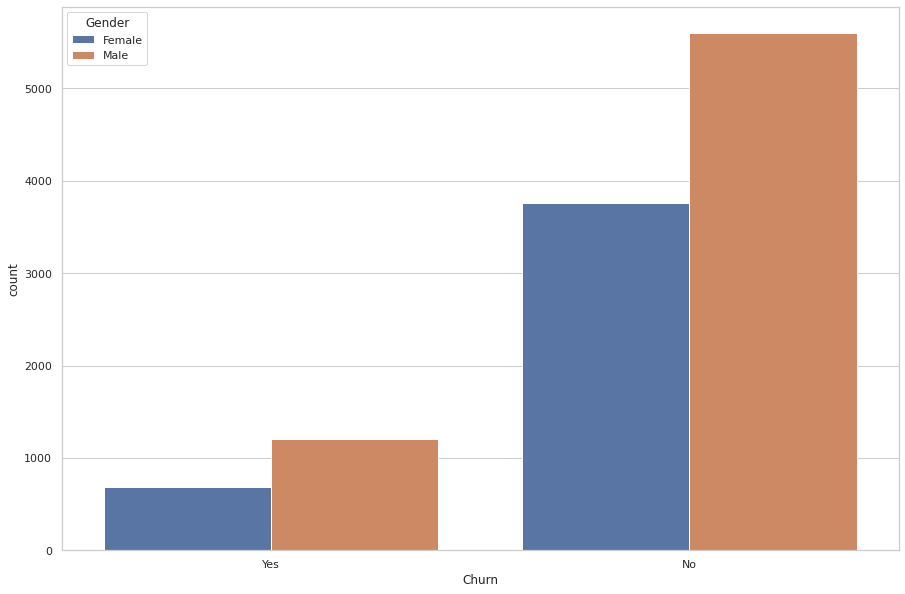

-----------------------------------------------


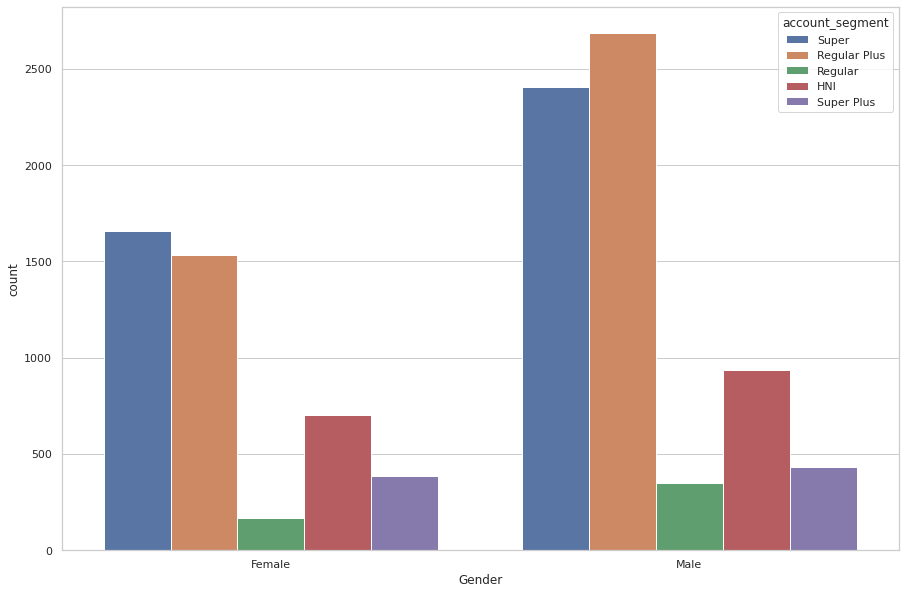

-----------------------------------------------


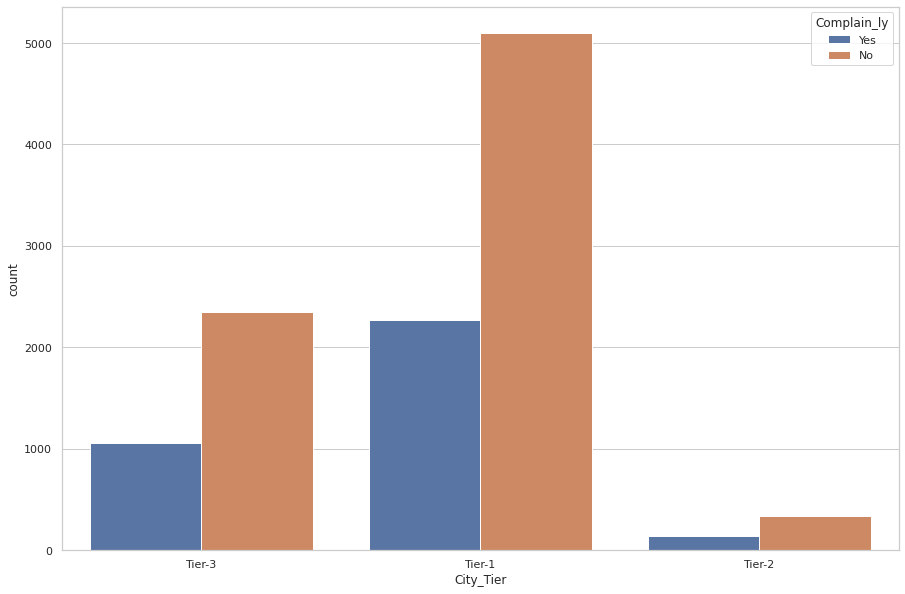

-----------------------------------------------


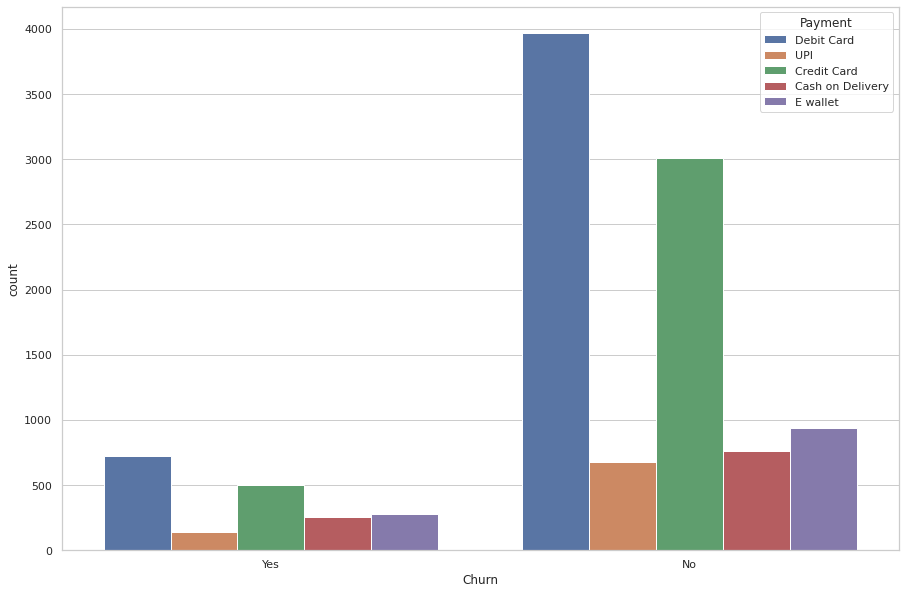

-----------------------------------------------


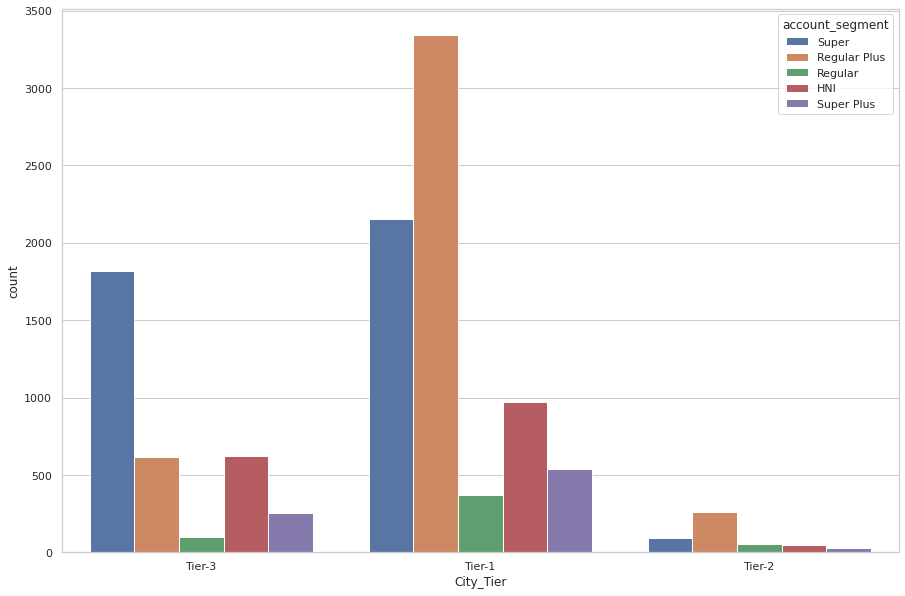

-----------------------------------------------


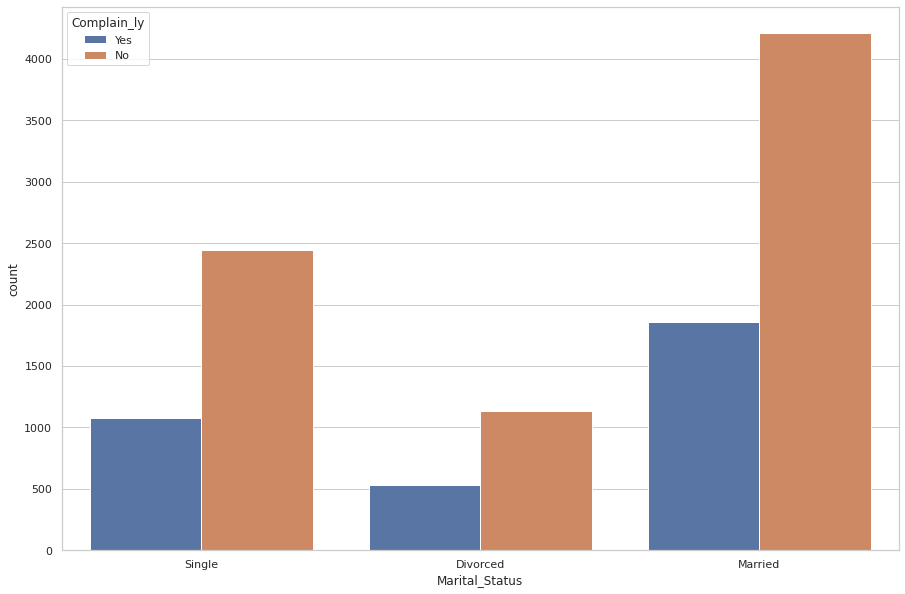

-----------------------------------------------


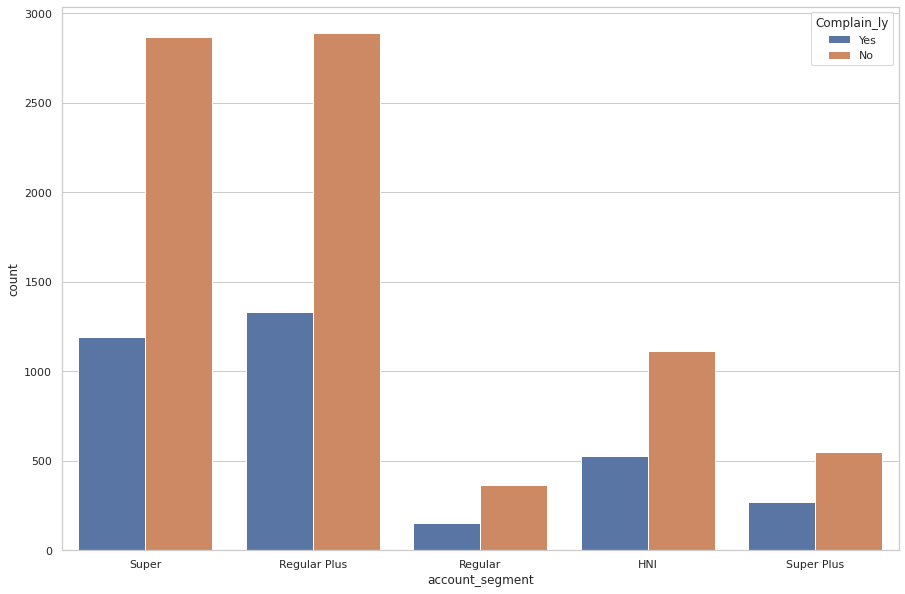

-----------------------------------------------


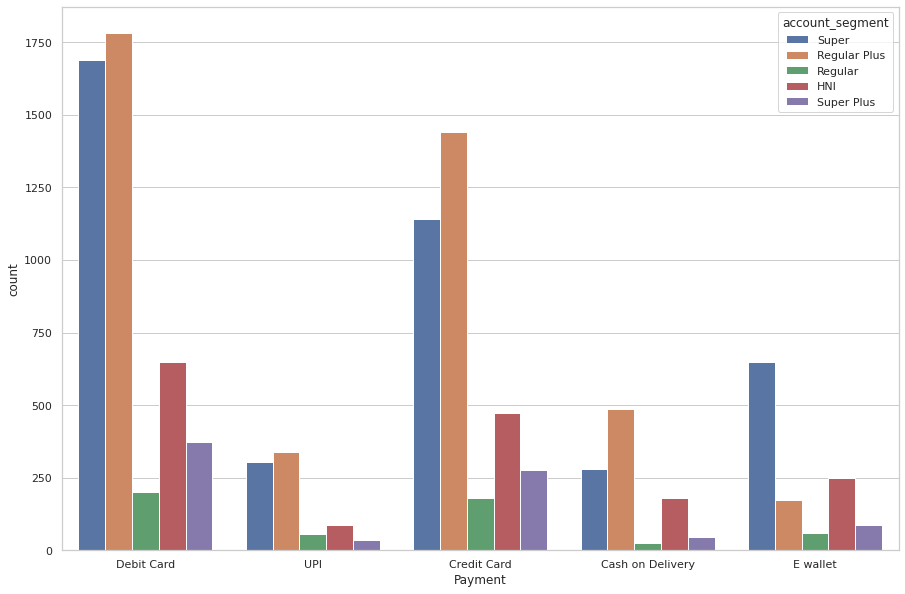

-----------------------------------------------


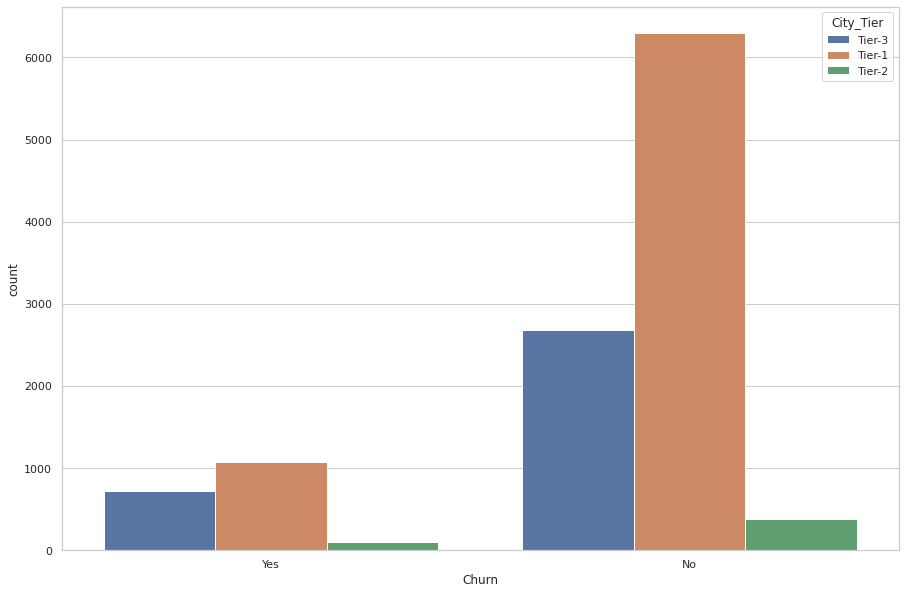

-----------------------------------------------


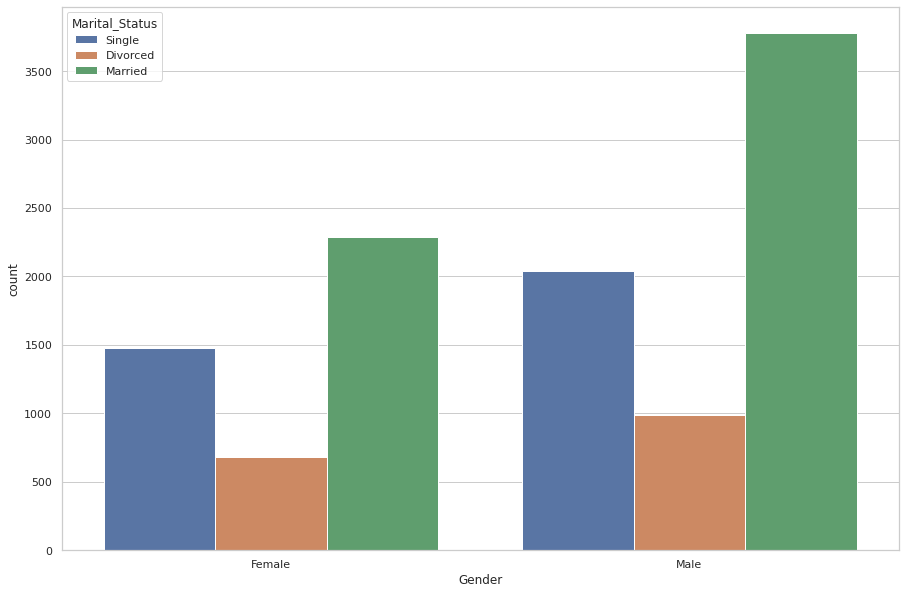

-----------------------------------------------


In [ ]:
for i,j in iter:
    plt.figure(figsize = (15,10))
    sns.countplot(x=i,data = df,hue=j);
    plt.show()
    print("-----------------------------------------------")


In [595]:
import itertools
iter_temp2 = list(itertools.combinations_with_replacement((num),2))
list_2=[('CC_Contacted_LY','CC_Contacted_LY'),
('Account_user_count','Account_user_count'),
('rev_growth_yoy','rev_growth_yoy'),
('coupon_used_for_payment','coupon_used_for_payment'),
('Tenure','Tenure'),
('CC_Agent_Score','CC_Agent_Score'),
('rev_per_month','rev_per_month'),
('Service_Score','Service_Score'),
('Day_Since_CC_connect','Day_Since_CC_connect'),
('cashback','cashback')]

iter_num= list(set(iter_temp2) - set(list_2))
iter_num

[('Account_user_count', 'rev_per_month'),
 ('Tenure', 'rev_per_month'),
 ('CC_Agent_Score', 'coupon_used_for_payment'),
 ('rev_per_month', 'coupon_used_for_payment'),
 ('Service_Score', 'coupon_used_for_payment'),
 ('Account_user_count', 'coupon_used_for_payment'),
 ('Account_user_count', 'Day_Since_CC_connect'),
 ('rev_per_month', 'rev_growth_yoy'),
 ('Service_Score', 'Day_Since_CC_connect'),
 ('CC_Agent_Score', 'rev_growth_yoy'),
 ('Tenure', 'coupon_used_for_payment'),
 ('CC_Agent_Score', 'rev_per_month'),
 ('rev_per_month', 'Day_Since_CC_connect'),
 ('Tenure', 'cashback'),
 ('CC_Contacted_LY', 'Day_Since_CC_connect'),
 ('Account_user_count', 'cashback'),
 ('Tenure', 'CC_Agent_Score'),
 ('Service_Score', 'cashback'),
 ('Service_Score', 'CC_Agent_Score'),
 ('Account_user_count', 'CC_Agent_Score'),
 ('rev_per_month', 'cashback'),
 ('rev_growth_yoy', 'Day_Since_CC_connect'),
 ('CC_Agent_Score', 'cashback'),
 ('Tenure', 'Account_user_count'),
 ('CC_Contacted_LY', 'rev_per_month'),
 ('Ten

In [ ]:
df["Churn"].value_counts(normalize=True)

No     0.831616
Yes    0.168384
Name: Churn, dtype: float64

### Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
df_CC_scaled = pd.DataFrame(std_scaler.fit_transform(df[con_var]),columns = list(df[con_var].columns))
df_CC_scaled.head()

,Tenure,CC_Contacted_LY,rev_per_month,rev_growth_yoy,Day_Since_CC_connect,cashback
0,-0.547428,-1.343771,0.228104,-1.382039,0.101471,-0.205137
1,-0.859567,-1.117169,0.055875,-0.317441,-1.264248,-0.426451
2,-0.859567,1.375447,-0.030240,-0.583591,-0.444817,-0.364029
3,-0.859567,-0.324064,0.141990,1.811754,-0.444817,-0.352680
4,-0.859567,-0.663967,-0.288583,-1.382039,-0.444817,-0.375378


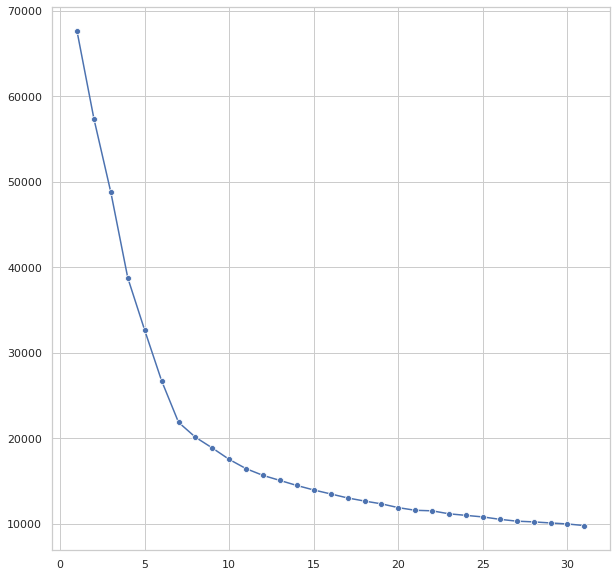

In [598]:
from sklearn.cluster import KMeans
SSD = []

for i in range(1,32):
    km = KMeans(n_clusters = i)
    km = km.fit(df_CC_scaled)
    SSD.append(km.inertia_)
fig,axes = plt.subplots(figsize=(10,10))
sns.lineplot(y = SSD,x = range(1,32),sort=False,marker = 'o')

Text(0.5, 1.0, 'Silhouette Score Plot')

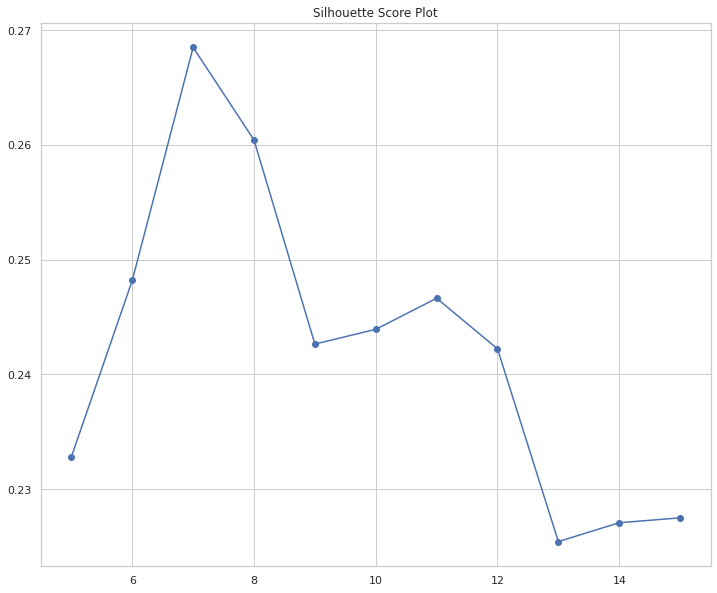

In [599]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sil_score = []
for i in range(5,16):
    k_means = KMeans(n_clusters = i,random_state=1234)
    k_means.fit(df_CC_scaled)
    clus = k_means.labels_
    sil_score.append(silhouette_score(df_CC_scaled,labels = clus))
fig,axes = plt.subplots(figsize=(12,10))
plt.plot(range(5,16),sil_score,marker='o')
axes.set_title('Silhouette Score Plot')

In [ ]:
clus_model = KMeans(n_clusters=7,random_state=1234)
clus_model.fit(df_CC_scaled)
df['Cluster_labels'] = clus_model.labels_

df['Cluster_labels'] = df['Cluster_labels'].map({0:'Clust-1',1:'Clust-2',2:'Clust-3',3:'Clust-4',4:'Clust-5',5:'Clust-6',6:'Clust-7'})

In [ ]:
df.head()

,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Churn,City_Tier,Payment,Gender,account_segment,Marital_Status,Complain_ly,Login_device,Cluster_labels
0,4.0,6.0,3.0,3.0,2.0,9.0,11.0,1.0,5.0,160.0,Yes,Tier-3,Debit Card,Female,Super,Single,Yes,Mobile,Clust-1
1,0.0,8.0,3.0,4.0,3.0,7.0,15.0,0.0,0.0,121.0,Yes,Tier-1,UPI,Male,Regular Plus,Single,Yes,Mobile,Clust-1
2,0.0,30.0,2.0,4.0,3.0,6.0,14.0,0.0,3.0,132.0,Yes,Tier-1,Debit Card,Male,Regular Plus,Single,Yes,Mobile,Clust-5
3,0.0,15.0,2.0,4.0,5.0,8.0,23.0,0.0,3.0,134.0,Yes,Tier-3,Debit Card,Male,Super,Single,No,Mobile,Clust-2
4,0.0,12.0,2.0,3.0,5.0,3.0,11.0,1.0,3.0,130.0,Yes,Tier-1,Credit Card,Male,Regular Plus,Single,No,Mobile,Clust-1


In [ ]:
df["Cluster_labels"].value_counts()

Clust-1    3811
Clust-6    2575
Clust-2    2379
Clust-5    2146
Clust-3     136
Clust-7     108
Clust-4     105
Name: Cluster_labels, dtype: int64

Text(0.5, 1.0, 'Size of the Clusters')

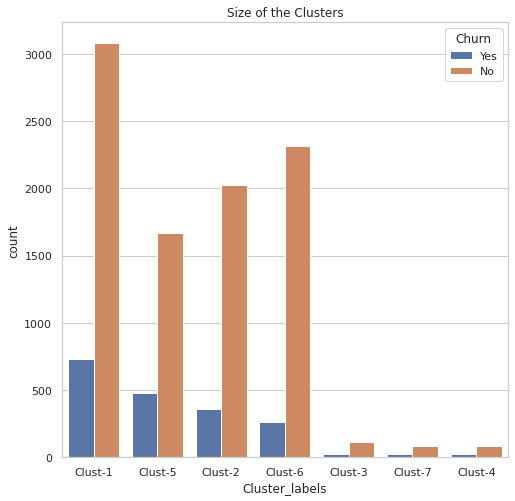

In [ ]:
fig,axes = plt.subplots(figsize=(8,8))
sns.countplot(x = 'Cluster_labels',data = df, hue="Churn")
axes.set_title('Size of the Clusters')

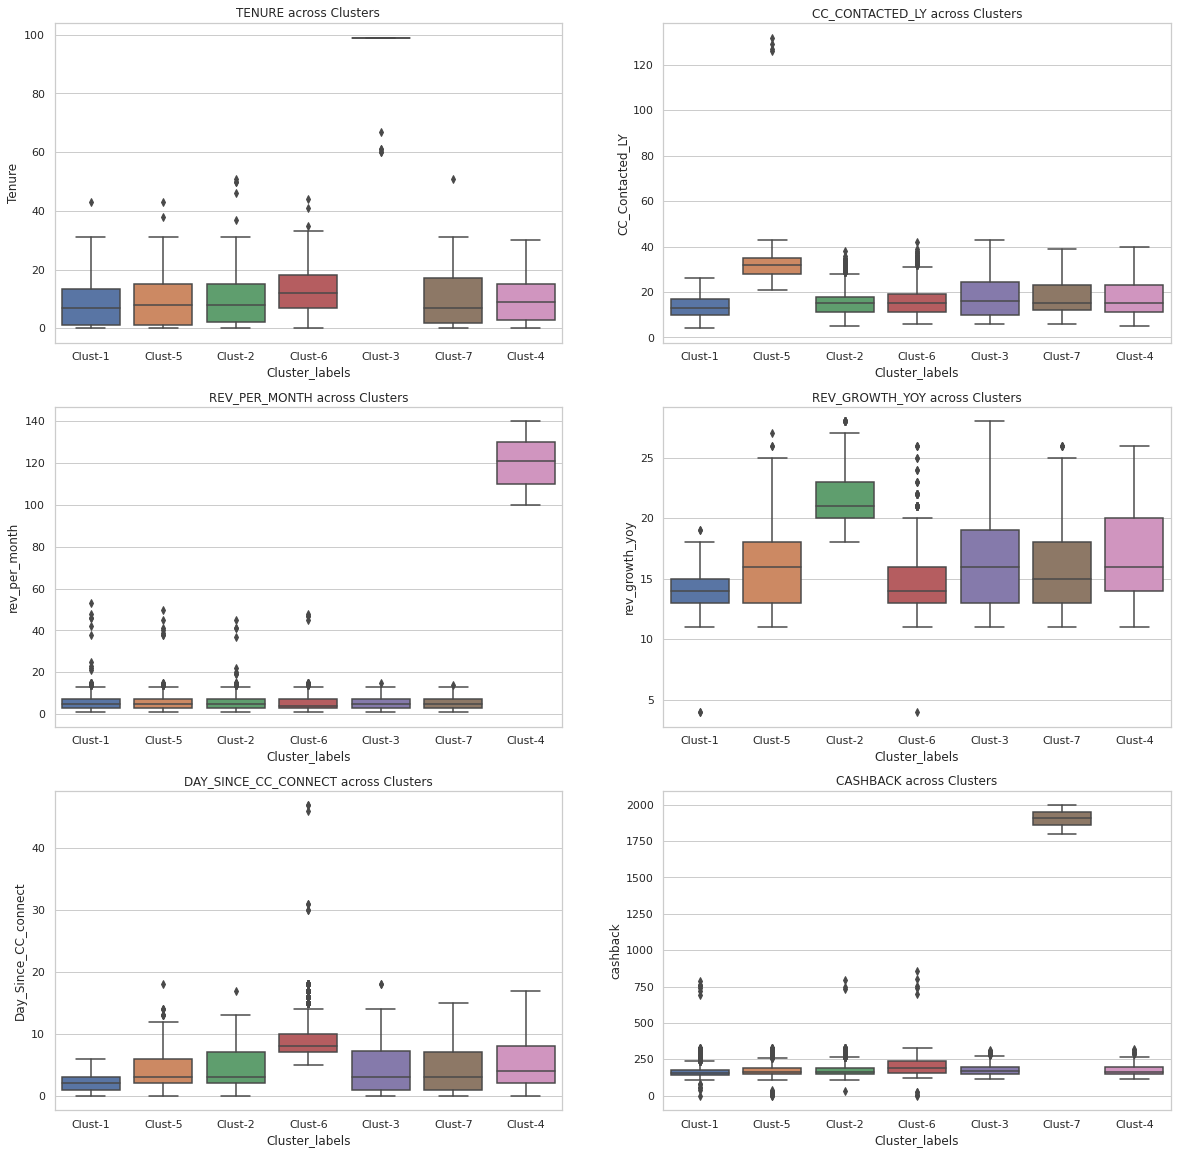

In [ ]:
fig,axes = plt.subplots(3,2,figsize=(20,20))
#plt.subplots_adjust(wspace=0.2,hspace=0.2)
for i,j in zip(con_var,axes.flatten()):
    sns.boxplot(x = 'Cluster_labels',y = i,data = df,ax = j)
    j.set_title('{} across Clusters'.format(i.upper()))


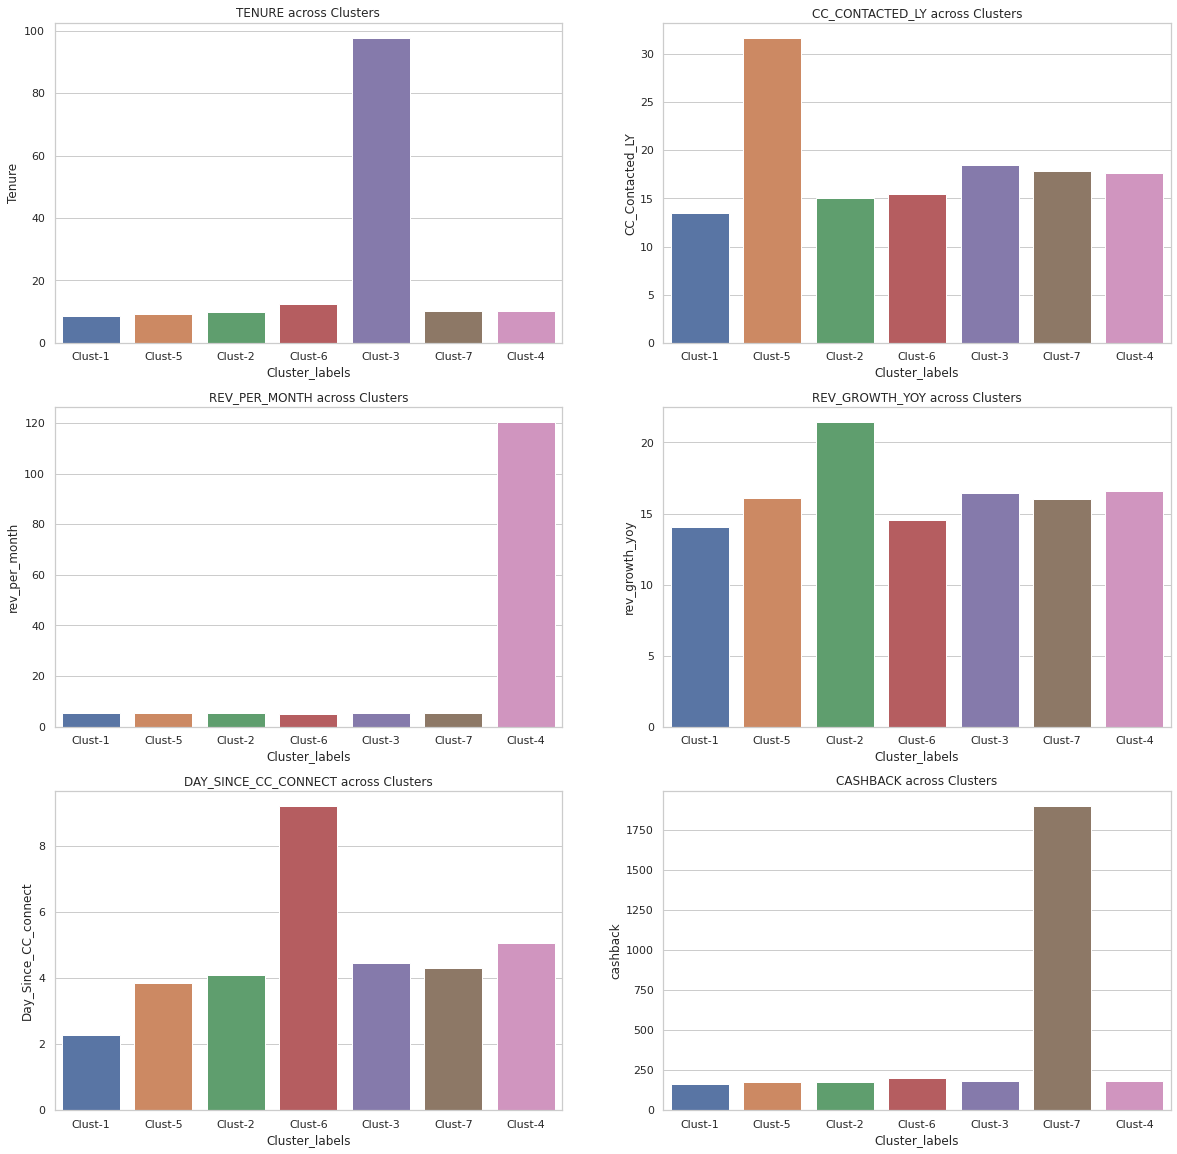

In [ ]:
fig,axes = plt.subplots(3,2,figsize=(20,20))
#plt.subplots_adjust(wspace=0.2,hspace=0.2)
for i,j in zip(con_var,axes.flatten()):
    sns.barplot(x = 'Cluster_labels',y = i,data = df,ax = j,ci=None)
    j.set_title('{} across Clusters'.format(i.upper()))

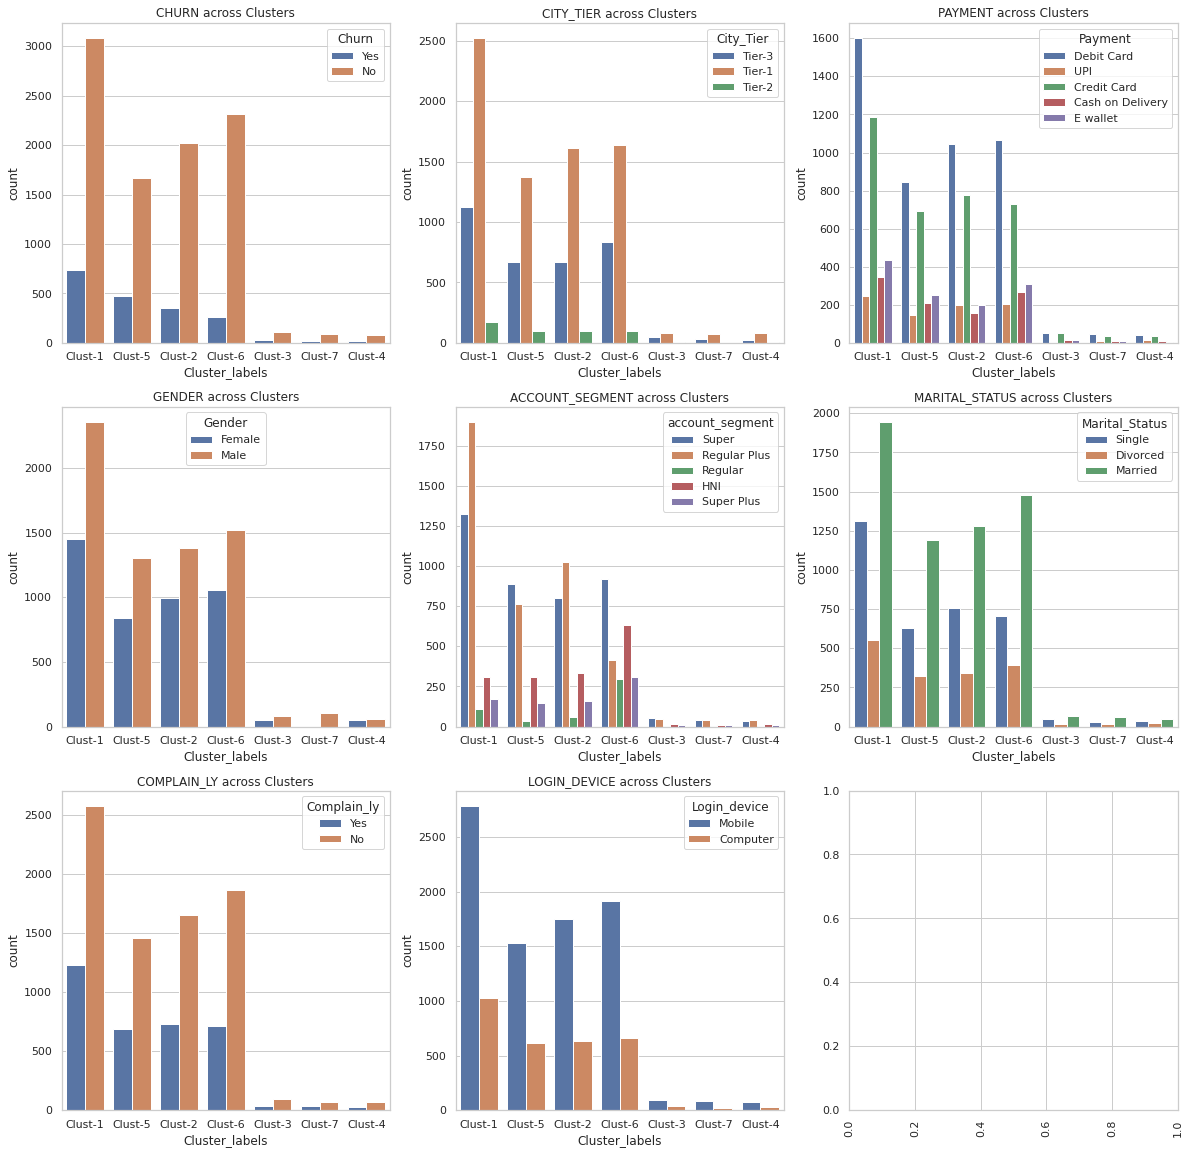

In [ ]:
fig,axes = plt.subplots(3,3,figsize=(20,20))
#plt.subplots_adjust(wspace=0.2,hspace=0.2)
for i,j in zip(cat,axes.flatten()):
    sns.countplot(x = 'Cluster_labels',data = df,ax = j,hue = i)
    j.set_title('{} across Clusters'.format(i.upper()))
    plt.xticks(rotation=90)

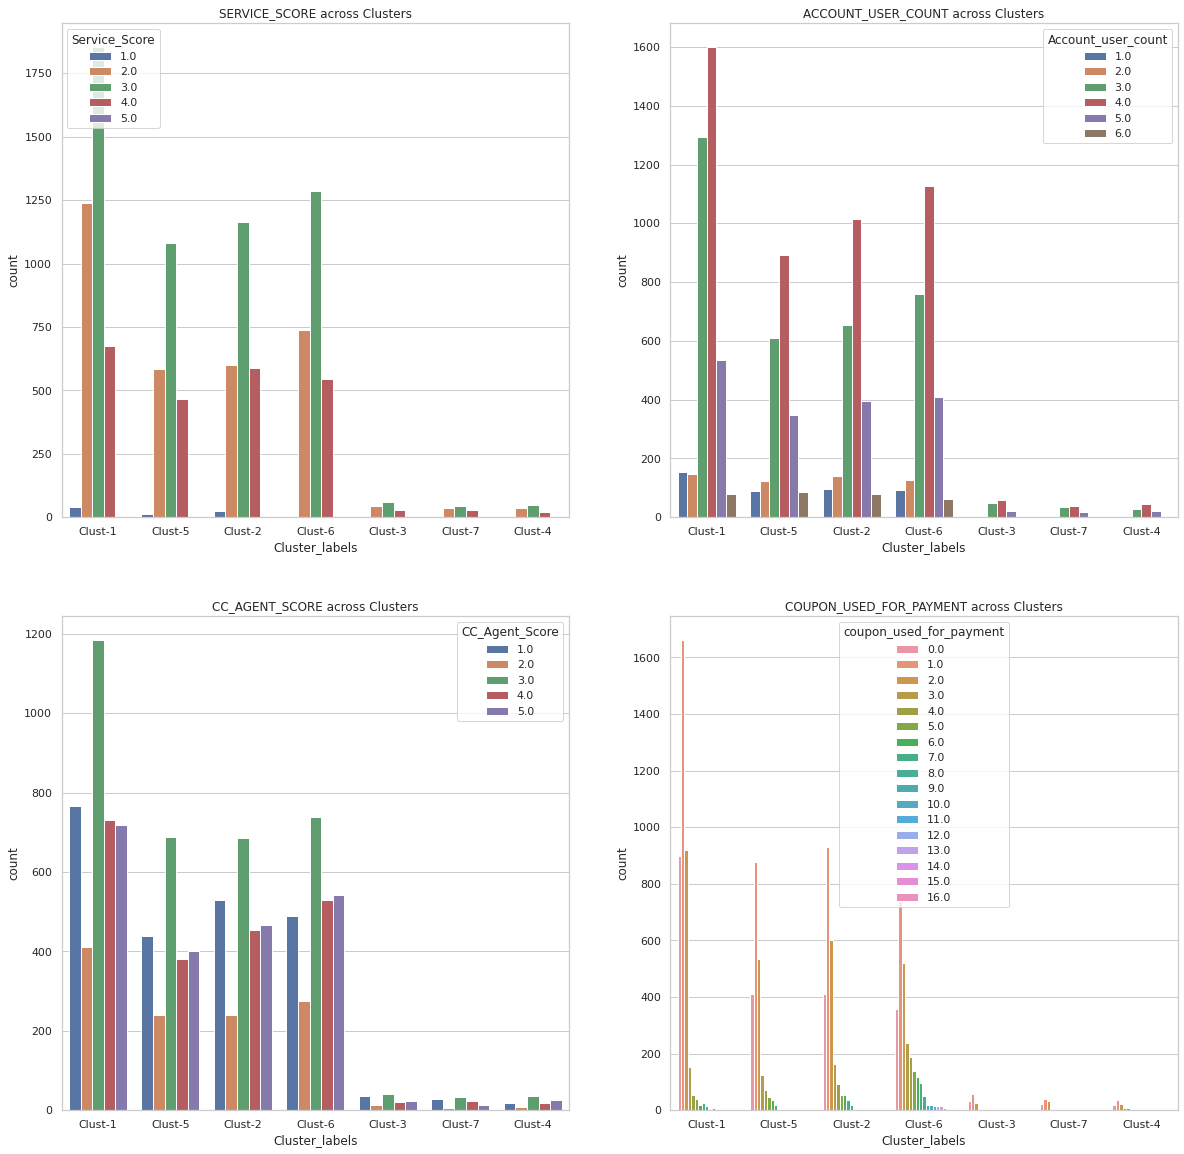

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(20,20))
#plt.subplots_adjust(wspace=0.2,hspace=0.2)
for i,j in zip(ord_var,axes.flatten()):
    sns.countplot(x = 'Cluster_labels',data = df,ax = j,hue = i)
    j.set_title('{} across Clusters'.format(i.upper()))

#----------------------------------------------------------------END OF NOTES 1-------------------------------------------------

#### Outlier handling

In [ ]:
df_cc_X = df.drop(['Default','Co_Code','Co_Name'], axis = 1)
df_cc_Y = df['Default']

In [ ]:

df_cc_X.boxplot(figsize=(20,7),color='c')
plt.xticks(rotation=90)
plt.title('With Outliers',fontsize=10)
plt.show()

In [ ]:
df_cc_X.head()

##### Finding Outliers

In [ ]:
def olf(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  ol=((df[column] < LB) | (df[column] > UB)).sum() 
  return print("Number of outliers in the column- {} is : {}".format(column,ol))

In [ ]:
olf('Equity_Paid_Up')

In [ ]:
for i in df_cc_X.columns:
    olf(i)

##### Treating the Outliers

In [ ]:
def olt(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  df[column]=np.where(df[column]>UB, UB, df[column])
  df[column]=np.where(df[column]<LB, LB, df[column])

In [ ]:
for i in df_cc_X.columns:
    olt(i)

In [ ]:
#Rechecking the outliers count. 
for i in df_cc_X.columns:
    olf(i)